# Ewaluacja CohortFACTM na danych Immucan IF — kompletny notebook

## 0 — Setup: importy, konfiguracja i funkcje pomocnicze

In [ ]:
import os, sys, time, warnings
sys.path.insert(0, os.path.abspath('..'))   # repo root (notebook żyje w cohort_tests_notebooks/)
sys.path.insert(0, os.path.abspath('.'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import linear_sum_assignment
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, normalized_mutual_info_score,
                             adjusted_mutual_info_score, fowlkes_mallows_score,
                             homogeneity_completeness_v_measure)
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering

from src import FACTModel
from src.enums import ZPrior

from scipy.stats import spearmanr

from immucan_data import immucan_model_config, load_immucan

import src.build_model as _bm
_bm.tqdm = lambda x, *a, **k: x

sns.set_context('notebook')
pd.set_option('display.width', 120)

# ----- globalne ustawienia eksperymentów -----
HEADLINE_K = 5      # K dla głównych eksperymentów (jak w covid_cohort_tests)
PI         = 0.5    # spike-and-slab P(gamma=1) — headline (0.5 lepszy niż 0.3, patrz sek. 6b)
MAX_ITER   = 60     # iteracje CAVI (zredukowane z 100 — duża siatka K x pi na 5 kohortach)
SEED       = 0
IMMUCAN_ROOT = '/Volumes/T7/immucan/results/IF/05_IF_table_extraction'
IMMUCAN_PANELS = ('IF1',)
IMMUCAN_COHORTS = None
IMMUCAN_SAMPLE_IDS = None
FIRST_N_PER_COHORT = 100
REBUILD_CACHE = False   # ustaw True po zmianie FIRST_N_PER_COHORT / TUMOR_ROI_ONLY
TUMOR_ROI_ONLY = True   # in.ROI.tumor_tissue == TRUE; False = wszystkie komórki z TSV

print(f'HEADLINE_K={HEADLINE_K}  PI={PI}  MAX_ITER={MAX_ITER}  SEED={SEED}')
print(f'panels={IMMUCAN_PANELS}  first_n_per_cohort={FIRST_N_PER_COHORT}  tumor_roi_only={TUMOR_ROI_ONLY}')

HEADLINE_K=5  PI=0.5  MAX_ITER=60  SEED=0
panels=('IF1',)  first_n_per_cohort=100  tumor_roi_only=True


In [2]:
# ----------------------- dopasowanie modeli -----------------------
def fit_cohort(views, K, pi=PI, max_iter=MAX_ITER, seed=SEED, n_topics=10):
    '''CohortFACTM: simple (Normal+ARD) + structured CTM + ZPrior.COHORT.'''
    cfg = immucan_model_config(
        views, K, z_prior=ZPrior.COHORT, pi=pi, n_topics=n_topics
    )
    m = FACTModel(views=views, K=K, model_config=cfg, seed=seed)
    m.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
    return m


def fit_baseline(views, K, max_iter=MAX_ITER, seed=SEED, n_topics=10):
    '''Baseline FACTM: simple + structured CTM, Z ~ N(0,1).'''
    cfg = immucan_model_config(
        views, K, z_prior=ZPrior.STD_NORMAL, n_topics=n_topics
    )
    m = FACTModel(views=views, K=K, model_config=cfg, seed=seed)
    m.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
    return m


def cohort_gamma_delta(model, K):
    '''Macierze (C, K): E[gamma] i E[delta]. Wiersze wg np.unique(cohorts).'''
    priors = model.fa.node_z.z_priors
    assert priors[0].__class__.__name__ == 'CohortZPrior', 'model nie ma cohort-prior'
    E_g = np.column_stack([priors[k].E_gamma for k in range(K)])
    E_d = np.column_stack([priors[k].E_delta for k in range(K)])
    return E_g, E_d


def extract_cohort_effects(model, cohort_labels, K):
    '''E[gamma], E[delta], nazwy kohort i ELBO z dopasowanego modelu kohortowego.'''
    E_g, E_d = cohort_gamma_delta(model, K)
    return {'E_gamma': E_g, 'E_delta': E_d,
            'cohorts': np.array(sorted(np.unique(cohort_labels))),
            'elbo': float(model.elbo_sequence[-1])}

In [3]:
# --------------- odległości / Hungarian / stabilność W ---------------
def cohort_dist(M):
    '''Parami odległość L2 między wierszami M (pozycje kohort w przestrzeni utajonej).'''
    diffs = M[:, None, :] - M[None, :, :]
    return np.sqrt(np.sum(diffs ** 2, axis=-1))


def cohort_positions(model, K):
    '''(C, K) pozycje kohort w przestrzeni utajonej z E[gamma * delta].'''
    pr = model.fa.node_z.z_priors
    return np.column_stack([pr[k].E_gamma * pr[k].E_delta for k in range(K)])


def hungarian(Z_a, Z_b):
    '''Dopasuj kolumny Z_b do Z_a maksymalizując sumę |corr|; zwraca perm i znaki.'''
    K = Z_a.shape[1]
    corr = np.array([[np.corrcoef(Z_a[:, i], Z_b[:, j])[0, 1]
                      for j in range(K)] for i in range(K)])
    row, col = linear_sum_assignment(-np.abs(corr))
    signs = np.sign(corr[row, col]); signs[signs == 0] = 1
    return col, signs.astype(float)


def w_stability(model_a, model_b, K):
    '''Per-widok per-czynnik |corr(W_a, W_b)| po dopasowaniu czynników przez Z.'''
    perm, signs = hungarian(model_a.get_latent_factors(),
                            model_b.get_latent_factors())
    out = []
    for v in range(len(model_a.fa.nodelist_w)):
        Wa = model_a.fa.nodelist_w[v].E_w
        Wb = model_b.fa.nodelist_w[v].E_w
        out.append(np.array([abs(np.corrcoef(Wa[:, k], Wb[:, perm[k]] * signs[k])[0, 1])
                             for k in range(K)]))
    return out, perm, signs


def severity_from_label(label):
    '''Etykieta kohorty -> pseudo-ordinal (analog pseudo-ordinal). grouped/binary mają sens; by_type nominale.'''
    s = str(label).strip().lower()
    if s in ('breast', 'lung', 'kidney', 'head_neck'):
        return {'breast': 1.0, 'lung': 2.0, 'kidney': 3.0, 'head_neck': 4.0}[s]
    if s in ('immucan', 'synergy'):
        return {'immucan': 0.0, 'synergy': 1.0}[s]
    type_ord = {'bc1': 0.0, 'nsclc': 1.0, 'rcc': 2.0, 'scchn1': 3.0, 'syg_bc1': 4.0, 'scchn3': 5.0}
    return type_ord.get(s, float('nan'))

In [4]:
# --------------- metryki klastrowania ---------------
def clustering_metrics(X, labels):
    '''silhouette / Calinski-Harabasz: wyżej=lepiej; Davies-Bouldin / within-between: niżej=lepiej.'''
    out = {}
    out['silhouette'] = float(silhouette_score(X, labels))
    out['davies_bouldin'] = float(davies_bouldin_score(X, labels))
    out['calinski_harabasz'] = float(calinski_harabasz_score(X, labels))
    uniq = np.unique(labels)
    cents = np.array([X[labels == c].mean(0) for c in uniq])
    within = np.mean([np.linalg.norm(X[labels == c] - cents[i], axis=1).mean()
                      for i, c in enumerate(uniq)])
    bp = cents[:, None, :] - cents[None, :, :]
    between = np.sqrt((bp ** 2).sum(-1))[np.triu_indices(len(cents), 1)].mean()
    out['within/between'] = float(within / between)
    return out


def cluster_cohorts(D, k_range=(2, 3, 4)):
    '''Agglomerative + k-means + spectral na macierzy odległości (C, C); silhouette per metoda.'''
    C = D.shape[0]
    rows, labels = [], {}
    coords = MDS(n_components=min(C - 1, 5), dissimilarity='precomputed',
                 random_state=0, n_init=4).fit_transform(D)
    for k in k_range:
        if k >= C:
            continue
        agg = AgglomerativeClustering(n_clusters=k, metric='precomputed',
                                      linkage='average').fit(D)
        sil_agg = silhouette_score(D, agg.labels_, metric='precomputed') \
            if len(set(agg.labels_)) > 1 else np.nan
        rows.append({'method': 'agglomerative', 'k': k, 'silhouette': sil_agg})
        labels[('agglomerative', k)] = agg.labels_
        km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(coords)
        sil_km = silhouette_score(D, km.labels_, metric='precomputed') \
            if len(set(km.labels_)) > 1 else np.nan
        rows.append({'method': 'kmeans', 'k': k, 'silhouette': sil_km})
        labels[('kmeans', k)] = km.labels_
        gamma = 1.0 / (2 * (D[D > 0].mean() ** 2 + 1e-9))
        A = np.exp(-gamma * D ** 2)
        sp = SpectralClustering(n_clusters=k, affinity='precomputed',
                                random_state=0, assign_labels='kmeans').fit(A)
        sil_sp = silhouette_score(D, sp.labels_, metric='precomputed') \
            if len(set(sp.labels_)) > 1 else np.nan
        rows.append({'method': 'spectral', 'k': k, 'silhouette': sil_sp})
        labels[('spectral', k)] = sp.labels_
    return pd.DataFrame(rows), labels


def cluster_samples(Z, true_labels, k_range=(2, 3, 4)):
    '''Klastruj N próbek w Z; silhouette + ARI/NMI vs prawdziwe etykiety kohort.'''
    rows, labels = [], {}
    true = np.asarray(true_labels)
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Z)
        agg = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(Z)
        for name, lab in [('kmeans', km.labels_), ('agglomerative', agg.labels_)]:
            sil = silhouette_score(Z, lab) if len(set(lab)) > 1 else np.nan
            h, comp, v = homogeneity_completeness_v_measure(true, lab)
            rows.append({'method': name, 'k': k, 'silhouette': sil,
                         'ARI': adjusted_rand_score(true, lab),
                         'NMI': normalized_mutual_info_score(true, lab),
                         'AMI': adjusted_mutual_info_score(true, lab),
                         'V_measure': v,
                         'FMI': fowlkes_mallows_score(true, lab)})
            labels[(name, k)] = lab
    if len(set(true)) > 1:
        rows.append({'method': 'TRUE_LABELS', 'k': len(set(true)),
                     'silhouette': silhouette_score(Z, true),
                     'ARI': 1.0, 'NMI': 1.0, 'AMI': 1.0,
                     'V_measure': 1.0, 'FMI': 1.0})
    return pd.DataFrame(rows), labels

In [5]:
# --------------- ładunki W, istotność faktorów, rekonstrukcja ---------------
def get_W(model, view_idx=0):
    '''Macierz ładunków E[W] (D x K) dla widoku prostego.'''
    return np.asarray(model.fa.nodelist_w[view_idx].E_w)


def factor_alpha(model, view_idx=0):
    '''ARD precyzja E[alpha] per faktor (małe = istotny, duże = wygaszony przez ARD).
    Fallback do 1/energia gdy węzeł ARD nie wystawia E_alpha.'''
    wn = model.fa.nodelist_w[view_idx]
    for attr in ('alpha_m_node', 'node_alpha', 'alpha_node'):
        node = getattr(wn, attr, None)
        if node is not None and hasattr(node, 'E_alpha'):
            return np.asarray(node.E_alpha)
    e = np.linalg.norm(np.asarray(wn.E_w), axis=0)
    return 1.0 / np.maximum(e, 1e-9)


def reconstruct(model, views, view_idx=0):
    '''Zwraca (Y, Y_hat = Z·Wᵀ) — obserwacje i rekonstrukcja widoku z modelu.'''
    Z = np.asarray(model.get_latent_factors())
    W = get_W(model, view_idx)
    Y = np.asarray(views.simple[view_idx].data)
    return Y, Z @ W.T


def r2_view(Y, Yh):
    '''R² całego widoku (1 = idealna rekonstrukcja).'''
    return 1.0 - ((Y - Yh) ** 2).sum() / ((Y - Y.mean(0)) ** 2).sum()


def n_relevant_factors(model, view_idx=0, rel_thr=0.05):
    '''Liczba faktorów o względnej energii ładunków ‖W[:,k]‖ > rel_thr * max.'''
    e = np.linalg.norm(get_W(model, view_idx), axis=0)
    return int((e / e.max() > rel_thr).sum()) if e.max() > 0 else 0


def mean_r2(model, views):
    '''Średnie R² rekonstrukcji po wszystkich widokach prostych.'''
    return float(np.mean([r2_view(*reconstruct(model, views, vi))
                          for vi in range(views.num_simple)]))


# --------------- CTM: topiki spatial per kohorta ---------------
def sample_topic_means(model, struct_idx=0):
    '''Średnia E[xi] po oknach spatial → wektor L topików per próbka (N x L).'''
    ctm = model.ctms[struct_idx]
    return np.vstack([xi.mean(axis=0) for xi in ctm.node_xi.vi_par])


def cohort_topic_profiles(model, cohorts, struct_idx=0):
    '''Macierz (C, L): średnia proporcja topików w kohocie.'''
    props = sample_topic_means(model, struct_idx)
    names = np.array(sorted(np.unique(cohorts)))
    prof = np.vstack([props[cohorts == c].mean(axis=0) for c in names])
    return names, prof


def topic_celltype_matrix(model, struct_idx=0):
    '''L x G — P(celltype | topic) z node_beta.'''
    return model.get_topics(struct_idx)


def top_celltypes_per_topic(beta, vocab, topn=3):
    '''Etykieta topiku = topn dominujących typów komórek.'''
    labels = []
    for li in range(beta.shape[0]):
        order = np.argsort(beta[li])[::-1][:topn]
        labels.append(', '.join(vocab[j] for j in order))
    return labels


def topic_discrimination_scores(prof):
    '''Zakres między kohortami per topic (większy = bardziej rozróżniający).'''
    return prof.max(axis=0) - prof.min(axis=0)


def topic_cohort_enrichment_table(names, prof, topic_labels, order=None, topn=5):
    '''Tabela: które kohorty mają więcej/mniej danego topiku (top rozróżniających).'''
    if order is None:
        order = np.argsort(topic_discrimination_scores(prof))[::-1]
    rows = []
    for t in order[:topn]:
        p = prof[:, t]
        rows.append({
            'topic': topic_labels[t],
            'max_kohorta': names[p.argmax()],
            'max_prop': round(float(p.max()), 3),
            'min_kohorta': names[p.argmin()],
            'min_prop': round(float(p.min()), 3),
            'roznica_max_min': round(float(p.max() - p.min()), 3),
        })
    return pd.DataFrame(rows)


def abscorr(a, b):
    '''|corr| odporne na stałe kolumny (zwraca nan zamiast błędu).'''
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    return abs(np.corrcoef(a, b)[0, 1])

def abscorr_spear(a, b):
    '''|Spearman rho| — korelacja rang, do zmiennych ordinalnych (np. pseudo-ordinal).'''
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    return abs(spearmanr(a, b)[0])

In [6]:
# --------------- dwupoziomowy cache (RAM -> dysk -> fit) dostępu do danych i fitów ---------------
import joblib
DATA = {}
FITS = {}
CACHE_DIR = '.fit_cache_immucan'          # trwały cache fitów między uruchomieniami (w .gitignore)
os.makedirs(CACHE_DIR, exist_ok=True)

_DEFAULT_IMMUCAN_ROOT = '/Volumes/T7/immucan/results/IF/05_IF_table_extraction'


def _data_cache_tag():
    '''Krótki tag — RAM/dysk fit cache unieważnia się po zmianie próbki lub filtrów.'''
    n = globals().get('FIRST_N_PER_COHORT', 10)
    tumor = int(globals().get('TUMOR_ROI_ONLY', True))
    panels = '-'.join(globals().get('IMMUCAN_PANELS', ('IF1',)))
    return f'n{n}_roi{tumor}_{panels}'


def get_data(mode):
    tag = _data_cache_tag()
    key = (mode, tag)
    if key not in DATA:
        DATA[key] = load_immucan(
            globals().get('IMMUCAN_ROOT', _DEFAULT_IMMUCAN_ROOT),
            panels=globals().get('IMMUCAN_PANELS', ('IF1',)),
            cohorts=globals().get('IMMUCAN_COHORTS', None),
            sample_ids=globals().get('IMMUCAN_SAMPLE_IDS', None),
            first_n_per_cohort=globals().get('FIRST_N_PER_COHORT', 10),
            cohort_mode=mode,
            tumor_roi_only=globals().get('TUMOR_ROI_ONLY', True),
            rebuild_cache=globals().get('REBUILD_CACHE', False),
            standardize=True,
            progress=True,
        )
    return DATA[key]


def get_fit(mode, kind, K=HEADLINE_K, pi=PI, max_iter=MAX_ITER, seed=SEED):
    '''Dopasuj lub wczytaj model `kind` ('cohort'/'baseline'). Cache: RAM -> dysk -> fit.

    Każdy fit jest zapisywany na dysk po policzeniu, więc przebiegi są WZNAWIALNE: jeśli
    notebook padnie w połowie, kolejne uruchomienie wczytuje gotowe fity w sekundy i liczy
    tylko brakujące. Baseline nie zależy od pi, więc jego klucz pomija pi.'''
    tag = _data_cache_tag()
    pi_key = round(float(pi), 3) if kind == 'cohort' else None
    key = (tag, mode, kind, K, pi_key, max_iter, seed)
    if key in FITS:
        return FITS[key]
    path = os.path.join(CACHE_DIR, '_'.join(str(x) for x in key).replace('.', 'p') + '.joblib')
    if os.path.exists(path):
        m = joblib.load(path)
        FITS[key] = m
        return m
    data = get_data(mode)
    views = data.views
    n_topics = data.n_topics
    t0 = time.time()
    if kind == 'cohort':
        m = fit_cohort(views, K=K, pi=pi, max_iter=max_iter, seed=seed, n_topics=n_topics)
    elif kind == 'baseline':
        m = fit_baseline(views, K=K, max_iter=max_iter, seed=seed, n_topics=n_topics)
    else:
        raise ValueError(kind)
    print(f'  [fit] {mode:12s} {kind:8s} K={K:<2d} pi={str(pi_key):<5} -> '
          f'ELBO={float(m.elbo_sequence[-1]):.0f}  ({time.time()-t0:.0f}s)')
    joblib.dump(m, path, compress=3)
    FITS[key] = m
    return m


def plot_cohort_effects(out, K, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(11, 0.55 * len(out['cohorts']) + 2))
    sns.heatmap(out['E_gamma'] * out['E_delta'], annot=True, fmt='.2f', cmap='coolwarm',
                center=0, xticklabels=[f'Z{k}' for k in range(K)],
                yticklabels=out['cohorts'], ax=axes[0])
    axes[0].set_title(f'{title_prefix} — E[gamma·delta] (profil kohortowy)')
    sns.heatmap(out['E_gamma'], annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
                xticklabels=[f'Z{k}' for k in range(K)],
                yticklabels=out['cohorts'], ax=axes[1])
    axes[1].set_title(f'{title_prefix} — E[gamma] (aktywacja)')
    plt.tight_layout(); plt.show()

## 1 — Wczytanie danych i przegląd partycji kohort


In [7]:
for mode in ['by_type', 'grouped', 'binary']:
    d = get_data(mode)
    v = d.views
    dims = ', '.join(f'simple{vi}={v.simple[vi].D}' for vi in range(v.num_simple))
    if v.num_structured:
        dims += f'  structured={v.num_structured} (L={d.n_topics}, G={v.structured[0].G})'
    print(f'=== {mode} ===  N={v.N}  {dims}')
    print(pd.Series(d.cohorts).value_counts().sort_index().to_string(), '\n')

Immucan: loading cache data/immucan_IF1_d4eeaef779d4.csv
Immucan: loading structured cache data/immucan_structured_IF1_f4bb2bb0e0d7.pkl
=== by_type ===  N=269  simple0=17  structured=1 (L=10, G=9)
BC1        13
NSCLC      76
RCC        61
SCCHN1     95
SYG_BC1    24 

Immucan: loading cache data/immucan_IF1_d4eeaef779d4.csv
Immucan: loading structured cache data/immucan_structured_IF1_f4bb2bb0e0d7.pkl
=== grouped ===  N=269  simple0=17  structured=1 (L=10, G=9)
breast       37
head_neck    95
kidney       61
lung         76 

Immucan: loading cache data/immucan_IF1_d4eeaef779d4.csv
Immucan: loading structured cache data/immucan_structured_IF1_f4bb2bb0e0d7.pkl
=== binary ===  N=269  simple0=17  structured=1 (L=10, G=9)
immucan    245
synergy     24 



## 2 — Eksperyment 1: `by_type` + iteracja po `K = 3…10, 15, 20`


ELBO  cohort=-12341395   baseline=-12341622


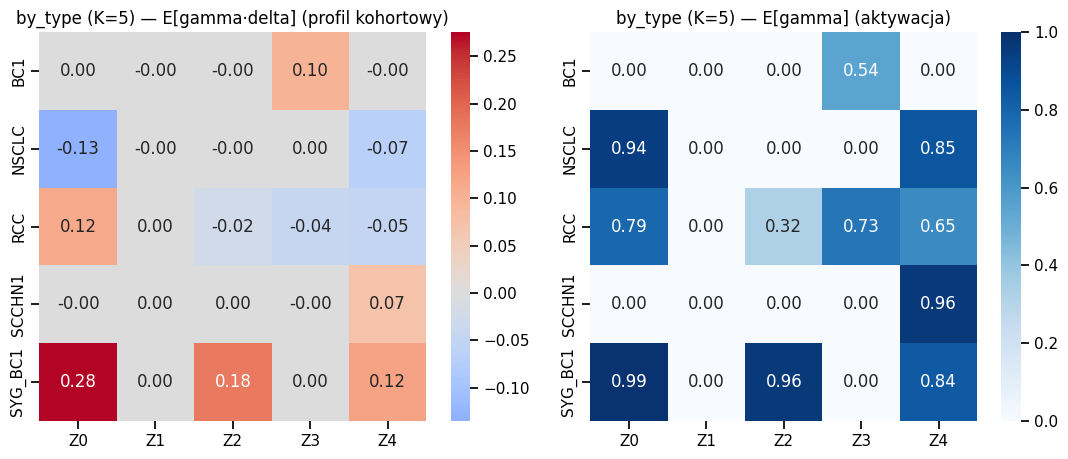

In [8]:
# --- Część A: headline K=5 ---
mode = 'by_type'
m  = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
out = extract_cohort_effects(m, get_data(mode).cohorts, K=HEADLINE_K)
print(f"ELBO  cohort={out['elbo']:.0f}   baseline={float(mb.elbo_sequence[-1]):.0f}")
plot_cohort_effects(out, HEADLINE_K, 'by_type (K=5)')

### 2a — Profil kohortowy: cohort vs baseline

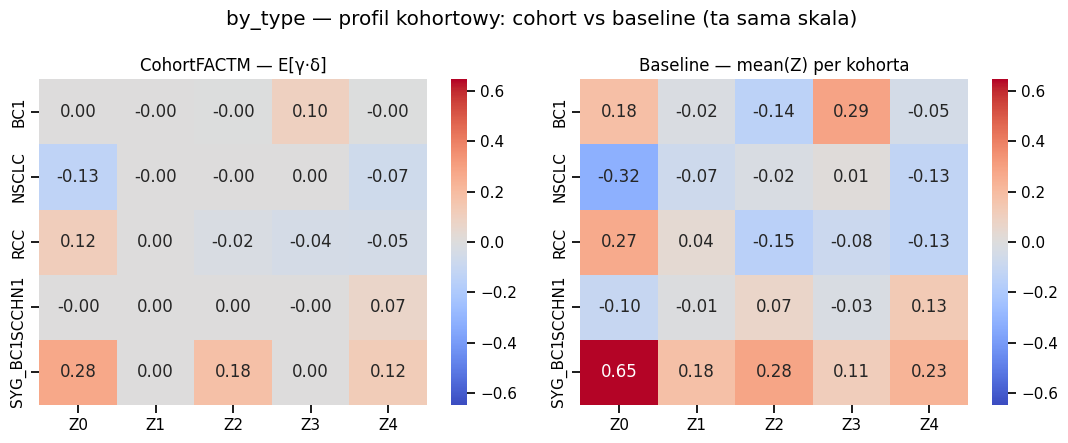

In [9]:
# Część A (baseline) — profil kohortowy baseline = mean(Z) per kohorta
# Baseline nie ma E[γ·δ]; jego odpowiednikiem profilu jest średnie Z_hat w obrębie kohorty
# (uśrednienie po pacjentach w danej grupie). Ta sama skala koloru = bezpośrednie porównanie.
mode = 'by_type'
d = get_data(mode)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
mc = get_fit(mode, 'cohort', K=HEADLINE_K)
names, codes = np.unique(d.cohorts, return_inverse=True)
prof_base = np.array([mb.get_latent_factors()[codes == i].mean(0) for i in range(len(names))])
out = extract_cohort_effects(mc, d.cohorts, K=HEADLINE_K)
prof_cohort = out['E_gamma'] * out['E_delta']
fl = [f'Z{k}' for k in range(HEADLINE_K)]
vmax = max(np.abs(prof_cohort).max(), np.abs(prof_base).max())

fig, axes = plt.subplots(1, 2, figsize=(11, 0.5 * len(names) + 2))
sns.heatmap(prof_cohort, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
            xticklabels=fl, yticklabels=names, ax=axes[0])
axes[0].set_title('CohortFACTM — E[γ·δ]')
sns.heatmap(prof_base, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
            xticklabels=fl, yticklabels=names, ax=axes[1])
axes[1].set_title('Baseline — mean(Z) per kohorta')
plt.suptitle('by_type — profil kohortowy: cohort vs baseline (ta sama skala)')
plt.tight_layout(); plt.show()

In [10]:
# --- Część B: sweep K = 3..10, 15, 20 ---
K_RANGE = [3, 4, 5, 6, 7, 8, 9, 10, 15, 20]
ACTIVE_THR = 0.5
views = get_data(mode).views
rows = []
for K in K_RANGE:
    mc = get_fit(mode, 'cohort',   K=K)
    mbk = get_fit(mode, 'baseline', K=K)
    E_g, _ = cohort_gamma_delta(mc, K)
    g_mean = E_g.mean(axis=0)
    rows.append({'K': K,
                 'elbo_cohort':   float(mc.elbo_sequence[-1]),
                 'elbo_baseline': float(mbk.elbo_sequence[-1]),
                 'n_active': int((g_mean > ACTIVE_THR).sum()),
                 'n_relevant_W': n_relevant_factors(mc, 0),
                 'R2_cohort': mean_r2(mc, views),
                 'R2_baseline': mean_r2(mbk, views)})
df_K = pd.DataFrame(rows)
df_K['elbo_gap'] = df_K['elbo_cohort'] - df_K['elbo_baseline']
print(df_K.round(3).to_string(index=False))

Pretraining CTM for structured view 0
Pretraining FA
Fitting model
  [fit] by_type      cohort   K=3  pi=0.5   -> ELBO=-12262936  (78s)
Pretraining CTM for structured view 0
Pretraining FA
Fitting model
  [fit] by_type      baseline K=3  pi=None  -> ELBO=-12262942  (76s)
Pretraining CTM for structured view 0
Pretraining FA
Fitting model
  [fit] by_type      cohort   K=4  pi=0.5   -> ELBO=-12289472  (76s)
Pretraining CTM for structured view 0
Pretraining FA
Fitting model
  [fit] by_type      baseline K=4  pi=None  -> ELBO=-12289611  (76s)
Pretraining CTM for structured view 0
Pretraining FA
Fitting model
  [fit] by_type      cohort   K=6  pi=0.5   -> ELBO=-12384453  (76s)
Pretraining CTM for structured view 0
Pretraining FA
Fitting model
  [fit] by_type      baseline K=6  pi=None  -> ELBO=-12384782  (76s)
Pretraining CTM for structured view 0
Pretraining FA
Fitting model
  [fit] by_type      cohort   K=7  pi=0.5   -> ELBO=-12352050  (76s)
Pretraining CTM for structured view 0
Pretrainin

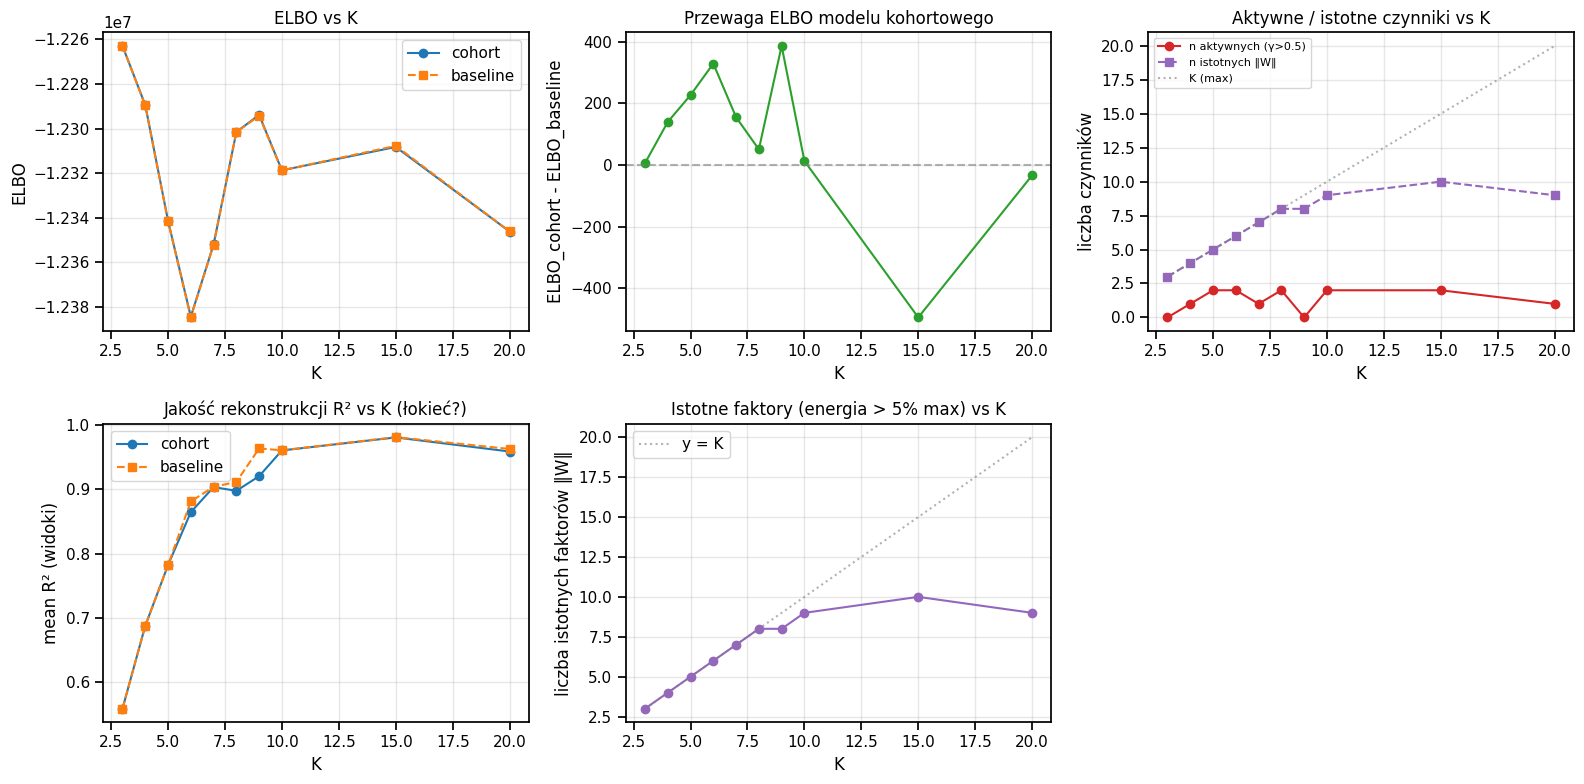

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].plot(df_K['K'], df_K['elbo_cohort'],   'o-', label='cohort')
axes[0, 0].plot(df_K['K'], df_K['elbo_baseline'], 's--', label='baseline')
axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('ELBO'); axes[0, 0].set_title('ELBO vs K')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(df_K['K'], df_K['elbo_gap'], 'o-', color='C2')
axes[0, 1].axhline(0, color='gray', ls='--', alpha=0.6)
axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('ELBO_cohort - ELBO_baseline')
axes[0, 1].set_title('Przewaga ELBO modelu kohortowego'); axes[0, 1].grid(alpha=0.3)

axes[0, 2].plot(df_K['K'], df_K['n_active'], 'o-', color='C3', label='n aktywnych (γ>0.5)')
axes[0, 2].plot(df_K['K'], df_K['n_relevant_W'], 's--', color='C4', label='n istotnych ‖W‖')
axes[0, 2].plot(df_K['K'], df_K['K'], ':', color='gray', alpha=0.6, label='K (max)')
axes[0, 2].set_xlabel('K'); axes[0, 2].set_ylabel('liczba czynników')
axes[0, 2].set_title('Aktywne / istotne czynniki vs K'); axes[0, 2].legend(fontsize=8)
axes[0, 2].grid(alpha=0.3)

axes[1, 0].plot(df_K['K'], df_K['R2_cohort'],   'o-', label='cohort')
axes[1, 0].plot(df_K['K'], df_K['R2_baseline'], 's--', label='baseline')
axes[1, 0].set_xlabel('K'); axes[1, 0].set_ylabel('mean R² (widoki)')
axes[1, 0].set_title('Jakość rekonstrukcji R² vs K (łokieć?)')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(df_K['K'], df_K['n_relevant_W'], 'o-', color='C4')
axes[1, 1].plot(df_K['K'], df_K['K'], ':', color='gray', alpha=0.6, label='y = K')
axes[1, 1].set_xlabel('K'); axes[1, 1].set_ylabel('liczba istotnych faktorów ‖W‖')
axes[1, 1].set_title('Istotne faktory (energia > 5% max) vs K')
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

axes[1, 2].axis('off')
plt.tight_layout(); plt.show()

## 3 — Eksperyment 2: `grouped` (breast / lung / kidney / head_neck)

ELBO  cohort=-12341383   baseline=-12341622


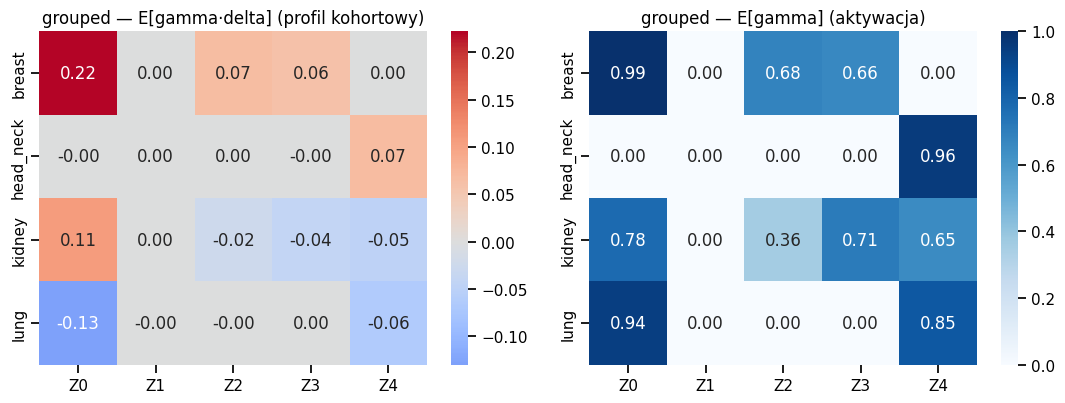

In [12]:
mode = 'grouped'
m  = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
out = extract_cohort_effects(m, get_data(mode).cohorts, K=HEADLINE_K)
print(f"ELBO  cohort={out['elbo']:.0f}   baseline={float(mb.elbo_sequence[-1]):.0f}")
plot_cohort_effects(out, HEADLINE_K, 'grouped')

## 4 — Eksperyment 3: `binary` (immucan / synergy)

ELBO  cohort=-12341347   baseline=-12341622


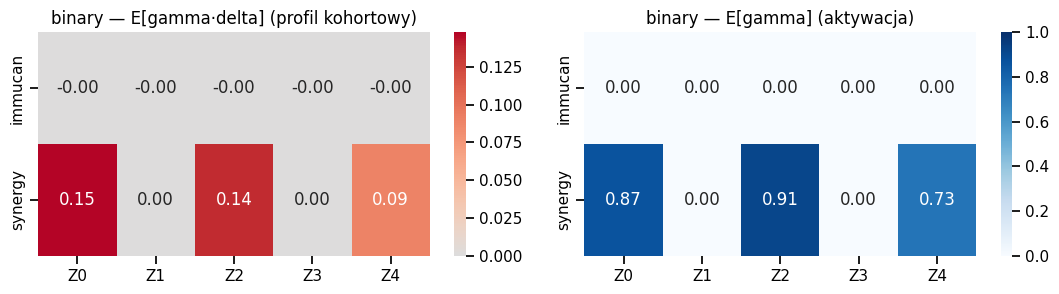

In [13]:
mode = 'binary'
m  = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
out = extract_cohort_effects(m, get_data(mode).cohorts, K=HEADLINE_K)
print(f"ELBO  cohort={out['elbo']:.0f}   baseline={float(mb.elbo_sequence[-1]):.0f}")
plot_cohort_effects(out, HEADLINE_K, 'binary')

## 5 — Eksperyment 4–5: struktura odległości kohort i korelacja z pseudo-ordinal

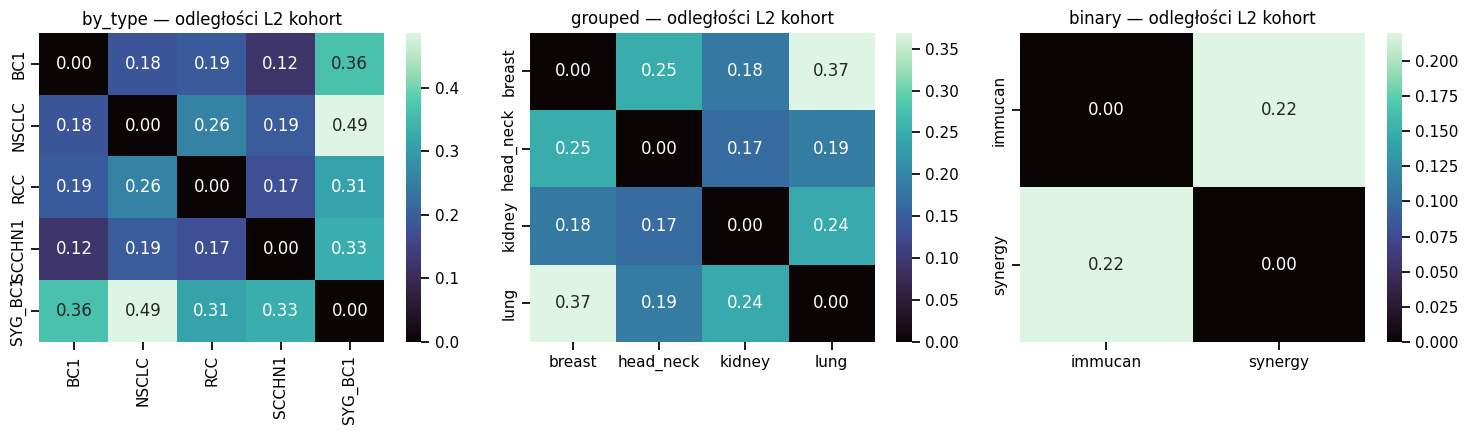

In [14]:
# Exp 4 — heatmapy odległości L2 dla trzech partycji
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, mode in zip(axes, ['by_type', 'grouped', 'binary']):
    m = get_fit(mode, 'cohort', K=HEADLINE_K)
    out = extract_cohort_effects(m, get_data(mode).cohorts, K=HEADLINE_K)
    M = out['E_gamma'] * out['E_delta']
    D = cohort_dist(M)
    sns.heatmap(D, annot=True, fmt='.2f', cmap='mako',
                xticklabels=out['cohorts'], yticklabels=out['cohorts'], ax=ax)
    ax.set_title(f'{mode} — odległości L2 kohort')
plt.tight_layout(); plt.show()

In [15]:
# Exp 5 — korelacja odległości z |różnicą pseudo-ordinal pseudo-ordinal|, cohort vs baseline
rows = []
for mode in ['grouped', 'by_type']:
    mc = get_fit(mode, 'cohort',   K=HEADLINE_K)
    mb = get_fit(mode, 'baseline', K=HEADLINE_K)
    d  = get_data(mode)
    out = extract_cohort_effects(mc, d.cohorts, K=HEADLINE_K)
    names = out['cohorts']

    D_fit = cohort_dist(out['E_gamma'] * out['E_delta'])                 # cohort
    Zh = mb.get_latent_factors()
    Z_means = np.array([Zh[d.cohorts == c].mean(axis=0) for c in names])
    D_base = cohort_dist(Z_means)                                        # baseline

    sev = np.array([severity_from_label(c) for c in names])
    D_sev = np.abs(sev[:, None] - sev[None, :])
    tri = np.triu_indices(len(names), 1)
    r_c = float(spearmanr(D_fit[tri],  D_sev[tri])[0])   # Spearman: D_sev z poziomów pseudo-ordinal
    r_b = float(spearmanr(D_base[tri], D_sev[tri])[0])
    rows.append({'mode': mode, 'n_cohorts': len(names),
                 'corr_cohort': r_c, 'corr_baseline': r_b,
                 'gap (cohort-baseline)': r_c - r_b})
print(pd.DataFrame(rows).round(3).to_string(index=False))

   mode  n_cohorts  corr_cohort  corr_baseline  gap (cohort-baseline)
grouped          4        0.062         -0.093                  0.154
by_type          5        0.311          0.102                  0.210


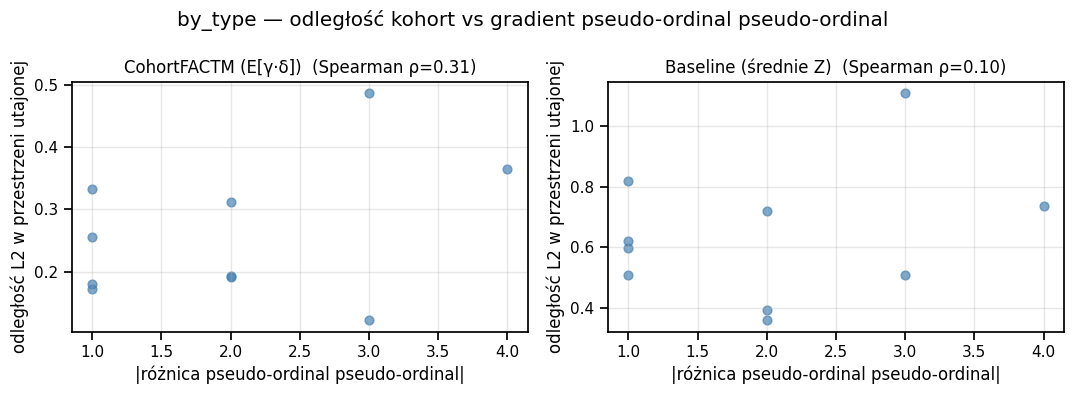

In [16]:
# Scatter: odległość utajona vs |różnica pseudo-ordinal| (by_type), cohort vs baseline
mode = 'by_type'
mc = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
d  = get_data(mode)
out = extract_cohort_effects(mc, d.cohorts, K=HEADLINE_K)
names = out['cohorts']

D_c = cohort_dist(out['E_gamma'] * out['E_delta'])
Z_means = np.array([mb.get_latent_factors()[d.cohorts == c].mean(axis=0) for c in names])
D_b = cohort_dist(Z_means)
sev = np.array([severity_from_label(c) for c in names])
D_sev = np.abs(sev[:, None] - sev[None, :])
tri = np.triu_indices(len(names), 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, D_fit, label in zip(axes, [D_c, D_b], ['CohortFACTM (E[γ·δ])', 'Baseline (średnie Z)']):
    r = float(spearmanr(D_fit[tri], D_sev[tri])[0])
    ax.scatter(D_sev[tri], D_fit[tri], s=40, alpha=0.7, color='steelblue')
    ax.set_xlabel('|różnica pseudo-ordinal pseudo-ordinal|'); ax.set_ylabel('odległość L2 w przestrzeni utajonej')
    ax.set_title(f'{label}  (Spearman ρ={r:.2f})'); ax.grid(alpha=0.3)
plt.suptitle('by_type — odległość kohort vs gradient pseudo-ordinal pseudo-ordinal')
plt.tight_layout(); plt.show()

## 6 — Test `pi` (z `01_pi_tests`) na danych Immucan dla `K ∈ {3, 5, 10}`

In [17]:
PI_GRID = [0.1, 0.3, 0.5, 0.7, 0.9]
K_FOR_PI = [3, 5, 10]
mode = 'by_type'
ACTIVE_THR = 0.5

rows = []
gamma_maps = {}   # K -> (n_factors, n_pi) macierz mean E[gamma]
for K in K_FOR_PI:
    cols = []
    for pi in PI_GRID:
        mp = get_fit(mode, 'cohort', K=K, pi=pi)
        E_g, _ = cohort_gamma_delta(mp, K)
        g_mean = E_g.mean(axis=0)
        cols.append(g_mean)
        rows.append({'K': K, 'pi': pi,
                     'n_active': int((g_mean > ACTIVE_THR).sum()),
                     'max_mean_gamma': float(g_mean.max()),
                     'elbo': float(mp.elbo_sequence[-1])})
    gamma_maps[K] = np.array(cols).T   # (K, len(PI_GRID))
df_pi = pd.DataFrame(rows)
print(df_pi.round(3).to_string(index=False))

Pretraining CTM for structured view 0
Pretraining FA
Fitting model
  [fit] by_type      cohort   K=3  pi=0.1   -> ELBO=-12262929  (83s)
Pretraining CTM for structured view 0
Pretraining FA
Fitting model
  [fit] by_type      cohort   K=3  pi=0.3   -> ELBO=-12262931  (83s)
Pretraining CTM for structured view 0
Pretraining FA
Fitting model
  [fit] by_type      cohort   K=3  pi=0.7   -> ELBO=-12262944  (83s)
Pretraining CTM for structured view 0
Pretraining FA
Fitting model
  [fit] by_type      cohort   K=3  pi=0.9   -> ELBO=-12262944  (83s)
Pretraining CTM for structured view 0
Pretraining FA
Fitting model
  [fit] by_type      cohort   K=5  pi=0.1   -> ELBO=-12341384  (82s)
Pretraining CTM for structured view 0
Pretraining FA
Fitting model
  [fit] by_type      cohort   K=5  pi=0.3   -> ELBO=-12341390  (82s)
Pretraining CTM for structured view 0
Pretraining FA
Fitting model
  [fit] by_type      cohort   K=5  pi=0.7   -> ELBO=-12341408  (82s)
Pretraining CTM for structured view 0
Pretrainin

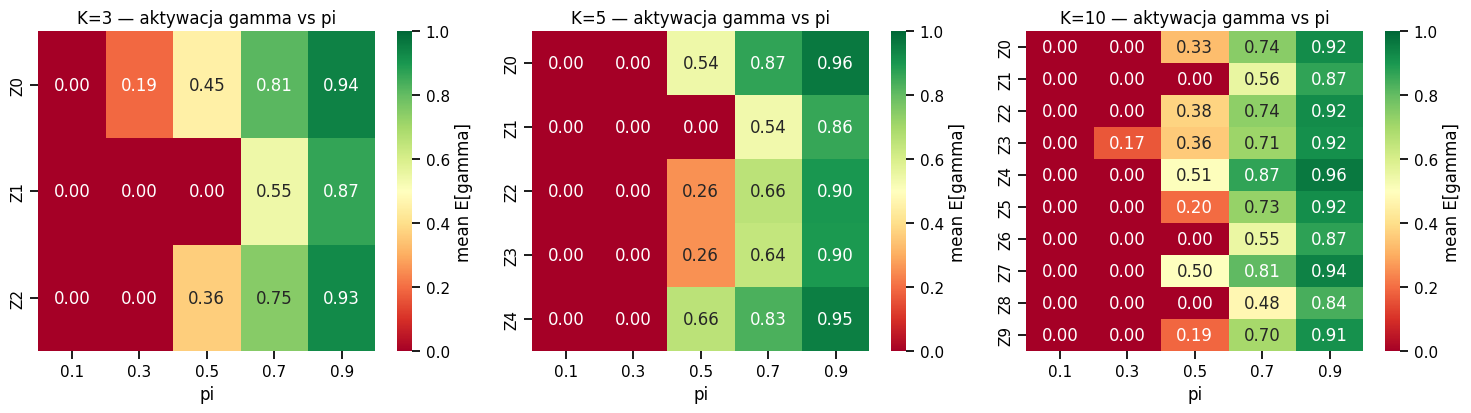

In [18]:
# Mapy aktywacji gamma (czynnik x pi) dla każdego K
fig, axes = plt.subplots(1, len(K_FOR_PI), figsize=(5 * len(K_FOR_PI), 0.8 + 0.35 * max(K_FOR_PI)))
for ax, K in zip(axes, K_FOR_PI):
    sns.heatmap(gamma_maps[K], annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
                xticklabels=[f'{p:g}' for p in PI_GRID],
                yticklabels=[f'Z{k}' for k in range(K)],
                cbar_kws={'label': 'mean E[gamma]'}, ax=ax)
    ax.set_xlabel('pi'); ax.set_title(f'K={K} — aktywacja gamma vs pi')
plt.tight_layout(); plt.show()

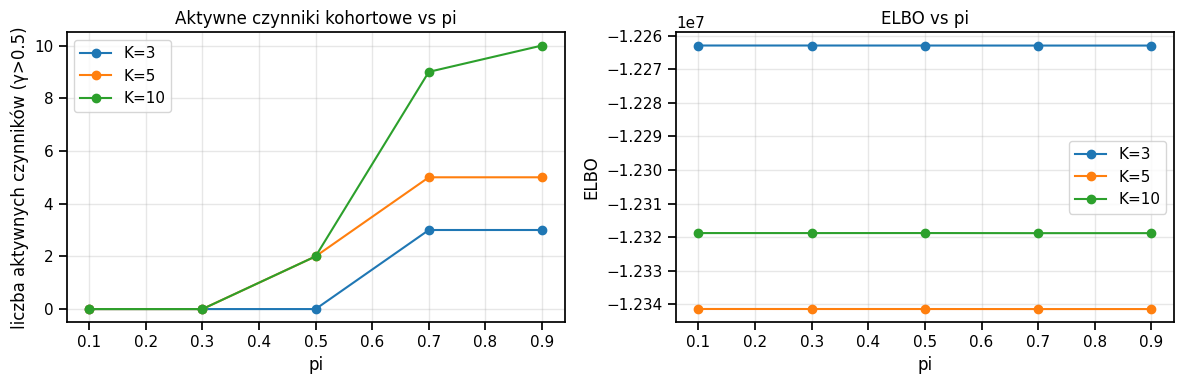

In [19]:
# n_active i ELBO vs pi dla trzech K
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for K in K_FOR_PI:
    sub = df_pi[df_pi['K'] == K]
    axes[0].plot(sub['pi'], sub['n_active'], 'o-', label=f'K={K}')
    axes[1].plot(sub['pi'], sub['elbo'],     'o-', label=f'K={K}')
axes[0].set_xlabel('pi'); axes[0].set_ylabel('liczba aktywnych czynników (γ>0.5)')
axes[0].set_title('Aktywne czynniki kohortowe vs pi'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('pi'); axes[1].set_ylabel('ELBO')
axes[1].set_title('ELBO vs pi'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 6b — Wybór `pi`: 0.3 vs 0.5 vs 0.7

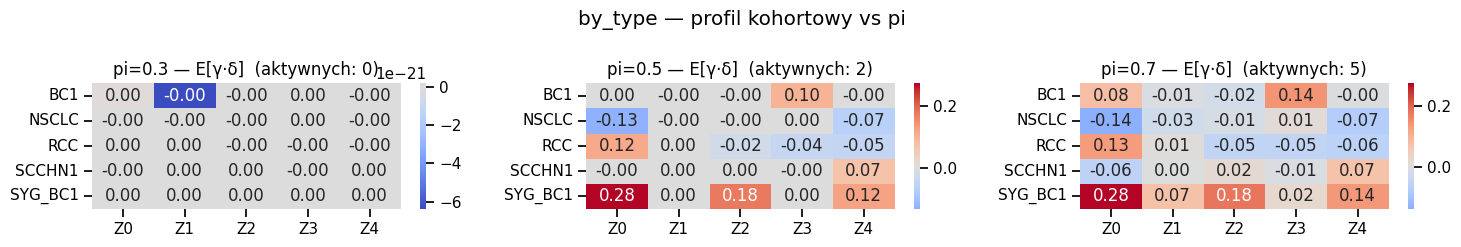

In [20]:
# 6b-1 — profil E[γ·δ] dla by_type przy pi = 0.3 / 0.5 / 0.7
PIS = [0.3, 0.5, 0.7]
mode = 'by_type'
d = get_data(mode)
names = np.array(sorted(np.unique(d.cohorts)))
fig, axes = plt.subplots(1, len(PIS), figsize=(5 * len(PIS), 0.5 + 0.4 * len(names)))
for ax, pi in zip(axes, PIS):
    m = get_fit(mode, 'cohort', K=HEADLINE_K, pi=pi)
    E_g, E_d = cohort_gamma_delta(m, HEADLINE_K)
    n_act = int((E_g.mean(0) > 0.5).sum())
    sns.heatmap(E_g * E_d, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                xticklabels=[f'Z{k}' for k in range(HEADLINE_K)], yticklabels=names, ax=ax)
    ax.set_title(f'pi={pi} — E[γ·δ]  (aktywnych: {n_act})')
plt.suptitle('by_type — profil kohortowy vs pi')
plt.tight_layout(); plt.show()

In [ ]:
PIS = [0.3, 0.5, 0.7]
rows = []
for mode in ['grouped', 'by_type']:
    d = get_data(mode)
    names = np.array(sorted(np.unique(d.cohorts)))
    sev = np.array([severity_from_label(c) for c in names])
    D_sev = np.abs(sev[:, None] - sev[None, :])
    tri = np.triu_indices(len(names), 1)
    Zb = get_fit(mode, 'baseline', K=HEADLINE_K).get_latent_factors()
    Zmb = np.array([Zb[d.cohorts == c].mean(0) for c in names])
    row = {'mode': mode, 'baseline': round(float(spearmanr(cohort_dist(Zmb)[tri], D_sev[tri])[0]), 3)}
    for pi in PIS:
        m = get_fit(mode, 'cohort', K=HEADLINE_K, pi=pi)
        E_g, E_d = cohort_gamma_delta(m, HEADLINE_K)
        D = cohort_dist(E_g * E_d)
        row[f'cohort_pi{pi}'] = round(float(spearmanr(D[tri], D_sev[tri])[0]), 3)
    rows.append(row)
print('Korelacja odległości kohort z |różnicą pseudo-ordinal| (wyżej = lepiej):')
print(pd.DataFrame(rows).to_string(index=False))

Korelacja odległości kohort z |różnicą pseudo-ordinal| (wyżej = lepiej):
   mode  baseline  cohort_pi0.3  cohort_pi0.5  cohort_pi0.7
grouped    -0.093        -0.062         0.062        -0.093
by_type     0.102         0.367         0.311         0.051


In [ ]:
PIS = [0.3, 0.5, 0.7]
rows = []
for mode in ['by_type', 'grouped', 'binary']:
    d = get_data(mode)
    _, codes = np.unique(d.cohorts, return_inverse=True)
    C = len(np.unique(codes))
    labb = KMeans(n_clusters=C, n_init=10, random_state=0).fit_predict(
        get_fit(mode, 'baseline', K=HEADLINE_K).get_latent_factors())
    row = {'mode': mode, 'baseline_ARI': round(adjusted_rand_score(codes, labb), 3)}
    for pi in PIS:
        lab = KMeans(n_clusters=C, n_init=10, random_state=0).fit_predict(
            get_fit(mode, 'cohort', K=HEADLINE_K, pi=pi).get_latent_factors())
        row[f'cohort_pi{pi}_ARI'] = round(adjusted_rand_score(codes, lab), 3)
    rows.append(row)
print('Odzysk kohort z Z_hat (ARI, wyżej = lepiej):')
print(pd.DataFrame(rows).to_string(index=False))

Odzysk kohort z Z_hat (ARI, wyżej = lepiej):
   mode  baseline_ARI  cohort_pi0.3_ARI  cohort_pi0.5_ARI  cohort_pi0.7_ARI
by_type        -0.002             0.010             0.011             0.009
grouped        -0.008             0.003             0.003             0.005
 binary         0.001            -0.006             0.001             0.004


## 7 — Struktura czynników `Z`

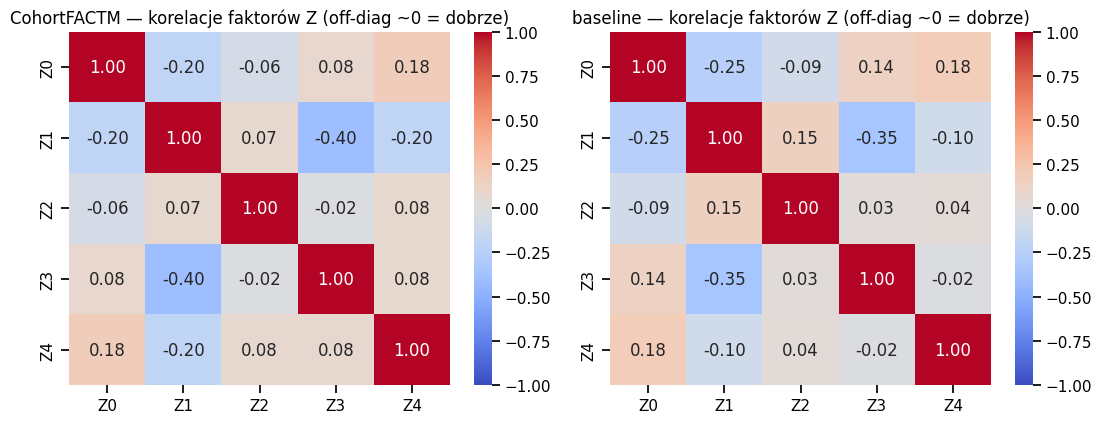

In [23]:
# 7a — korelacje między faktorami Z: cohort vs baseline
mode = 'by_type'
mc = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
d = get_data(mode)
factors = [f'Z{k}' for k in range(HEADLINE_K)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (mdl, name) in zip(axes, [(mc, 'CohortFACTM'), (mb, 'baseline')]):
    sns.heatmap(np.corrcoef(mdl.get_latent_factors().T), annot=True, fmt='.2f',
                cmap='coolwarm', center=0, vmin=-1, vmax=1,
                xticklabels=factors, yticklabels=factors, ax=ax)
    ax.set_title(f'{name} — korelacje faktorów Z (off-diag ~0 = dobrze)')
plt.tight_layout(); plt.show()

    var(Z[:,k])  ‖W0[:,k]‖ (energia)  |ρ(Z, pseudo-ordinal)| Spearman
Z0        0.231                3.148                            0.091
Z1        0.131                5.308                            0.086
Z2        0.137                3.940                            0.144
Z3        0.060                6.728                            0.078
Z4        0.077                5.689                            0.265

Faktor najsilniej powiązany z różnicą pseudo-ordinal pseudo-ordinal: Z4  (|corr|=0.265)


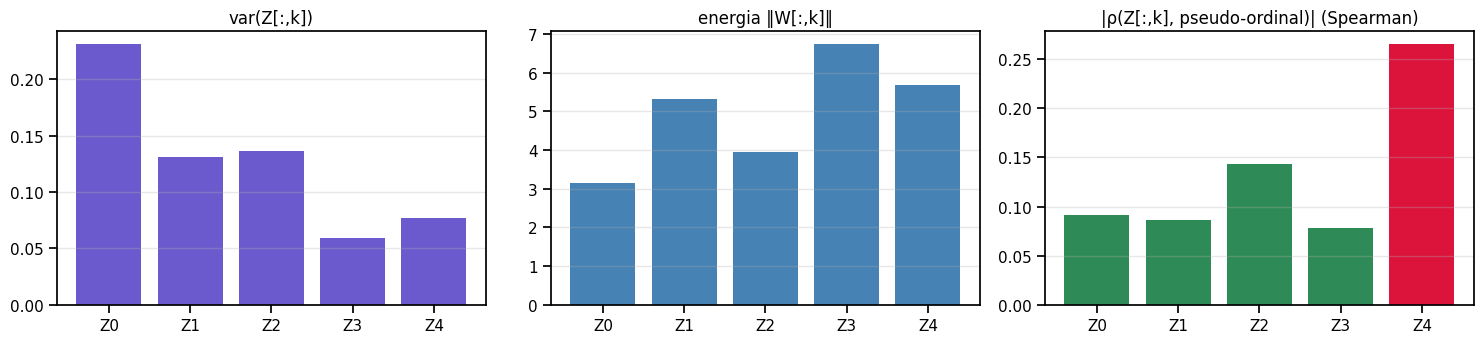

In [24]:
# 7b — istotność faktora i powiązanie z różnicą pseudo-ordinal pseudo-ordinal (model kohortowy)
Z = mc.get_latent_factors()
energy = np.linalg.norm(get_W(mc, 0), axis=0)
zvar = Z.var(0)
sev = d.severity.astype(float)
fac_sev = np.array([abscorr_spear(Z[:, k], sev) for k in range(HEADLINE_K)])  # Spearman: pseudo-ordinal ordinalne

tab = pd.DataFrame({'var(Z[:,k])': zvar.round(3),
                    '‖W0[:,k]‖ (energia)': energy.round(3),
                    '|ρ(Z, pseudo-ordinal)| Spearman': fac_sev.round(3)}, index=factors)
print(tab.to_string())
print(f'\nFaktor najsilniej powiązany z różnicą pseudo-ordinal pseudo-ordinal: '
      f'{factors[int(np.nanargmax(fac_sev))]}  (|corr|={np.nanmax(fac_sev):.3f})')

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].bar(factors, zvar, color='slateblue');  axes[0].set_title('var(Z[:,k])')
axes[1].bar(factors, energy, color='steelblue'); axes[1].set_title('energia ‖W[:,k]‖')
colors = ['crimson' if k == int(np.nanargmax(fac_sev)) else 'seagreen' for k in range(HEADLINE_K)]
axes[2].bar(factors, fac_sev, color=colors);     axes[2].set_title('|ρ(Z[:,k], pseudo-ordinal)| (Spearman)')
for ax in axes:
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

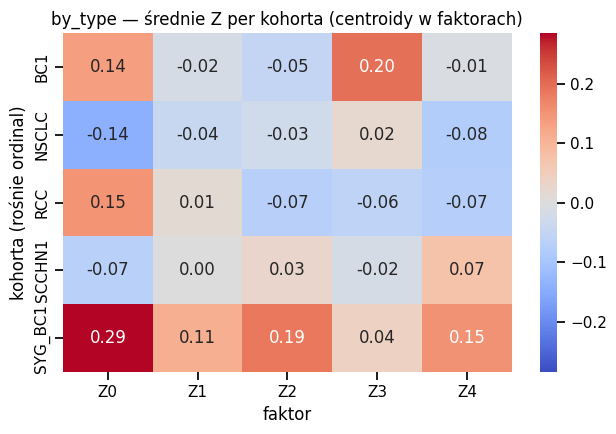

In [25]:
# 7c — centroidy kohort w przestrzeni faktorów (mean Z per kohorta)
names, codes = np.unique(d.cohorts, return_inverse=True)
cent = np.array([Z[codes == i].mean(0) for i in range(len(names))])
vmax = np.abs(cent).max()
fig, ax = plt.subplots(figsize=(6.5, 0.5 * len(names) + 2))
sns.heatmap(cent, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
            xticklabels=factors, yticklabels=names, ax=ax)
ax.set_title('by_type — średnie Z per kohorta (centroidy w faktorach)')
ax.set_xlabel('faktor'); ax.set_ylabel('kohorta (rośnie ordinal)')
plt.tight_layout(); plt.show()

## 8 — Klastrowanie i metryki separacji

In [26]:
# 8a — metryki separacji Z_hat: cohort vs baseline, dla trzech partycji
rows = []
for mode in ['by_type', 'grouped', 'binary']:
    d = get_data(mode)
    codes = np.unique(d.cohorts, return_inverse=True)[1]
    for kind in ['cohort', 'baseline']:
        m = get_fit(mode, kind, K=HEADLINE_K)
        mets = clustering_metrics(m.get_latent_factors(), codes)
        rows.append({'mode': mode, 'model': kind, **{k: round(v, 3) for k, v in mets.items()}})
df_sep = pd.DataFrame(rows)
print(df_sep.to_string(index=False))

   mode    model  silhouette  davies_bouldin  calinski_harabasz  within/between
by_type   cohort      -0.071           5.943              4.128           1.998
by_type baseline      -0.078           6.288              4.290           1.974
grouped   cohort      -0.040           6.176              4.785           2.241
grouped baseline      -0.052           6.143              4.973           2.191
 binary   cohort      -0.040           3.125              5.854           1.562
 binary baseline      -0.028           2.783              7.266           1.391


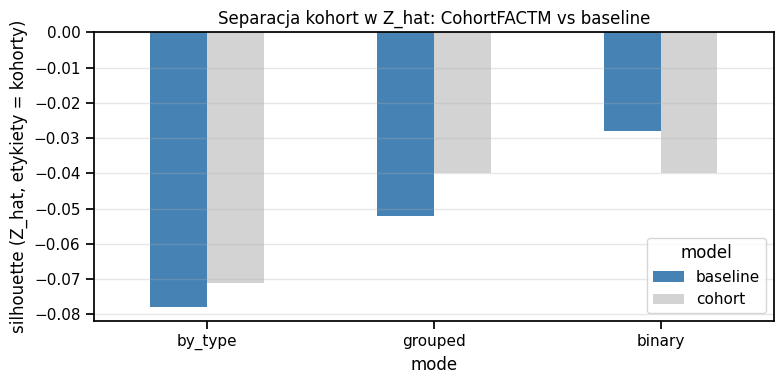

In [27]:
# 8b — wykres porównawczy silhouette (cohort vs baseline) per partycja
piv = df_sep.pivot(index='mode', columns='model', values='silhouette').loc[
    ['by_type', 'grouped', 'binary']]
ax = piv.plot.bar(figsize=(8, 4), color=['steelblue', 'lightgray'], rot=0)
ax.set_ylabel('silhouette (Z_hat, etykiety = kohorty)')
ax.set_title('Separacja kohort w Z_hat: CohortFACTM vs baseline')
ax.grid(alpha=0.3, axis='y'); plt.tight_layout(); plt.show()

Klastrowanie na poziomie kohort (D_fit, by_type):
       method  k  silhouette
agglomerative  2       0.393
       kmeans  2       0.393
     spectral  2       0.393
agglomerative  3       0.132
       kmeans  3       0.132
     spectral  3       0.113
agglomerative  4       0.123
       kmeans  4       0.123
     spectral  4      -0.053


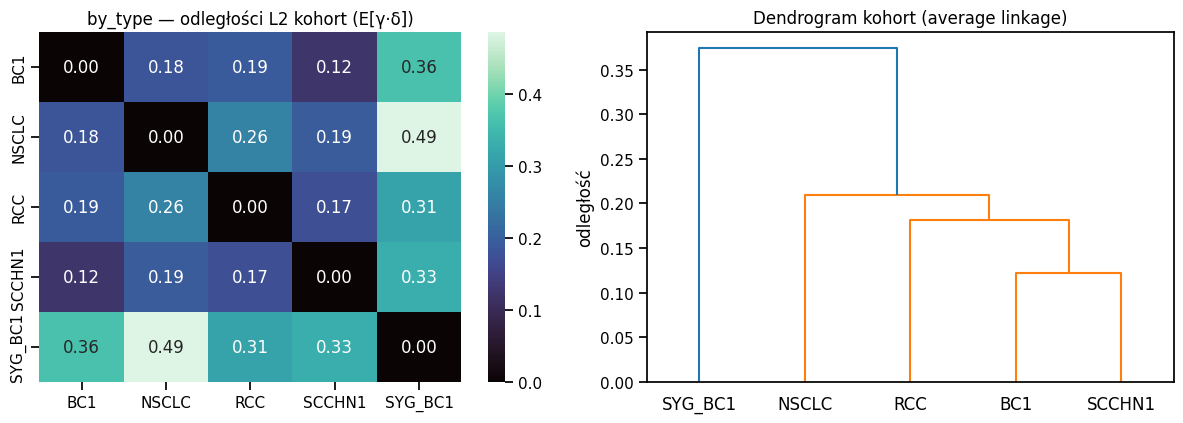

In [28]:
# 8c — klastrowanie na poziomie kohort (by_type): macierz odległości E[γ·δ]
mode = 'by_type'
mc = get_fit(mode, 'cohort', K=HEADLINE_K)
d = get_data(mode)
out = extract_cohort_effects(mc, d.cohorts, K=HEADLINE_K)
names = out['cohorts']
M_fit = out['E_gamma'] * out['E_delta']
D_fit = cohort_dist(M_fit)

df_cc, labels_cc = cluster_cohorts(D_fit, k_range=(2, 3, 4))
print('Klastrowanie na poziomie kohort (D_fit, by_type):')
print(df_cc.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
sns.heatmap(D_fit, annot=True, fmt='.2f', cmap='mako',
            xticklabels=names, yticklabels=names, ax=axes[0])
axes[0].set_title('by_type — odległości L2 kohort (E[γ·δ])')
Zlink = linkage(squareform(D_fit, checks=False), method='average')
dendrogram(Zlink, labels=list(names), ax=axes[1],
           color_threshold=0.7 * Zlink[:, 2].max())
axes[1].set_title('Dendrogram kohort (average linkage)'); axes[1].set_ylabel('odległość')
plt.tight_layout(); plt.show()

Porownanie per partycja (k-means k = liczba kohort):
   mode    model  k          ELBO    R2  silhouette    ARI   NMI   AMI  V_measure   FMI
by_type   cohort  5 -1.234140e+07 0.782      -0.071  0.011 0.058 0.038      0.058 0.259
by_type baseline  5 -1.234162e+07 0.782      -0.078 -0.002 0.044 0.023      0.044 0.250
grouped   cohort  4 -1.234138e+07 0.782      -0.040  0.003 0.041 0.028      0.041 0.276
grouped baseline  4 -1.234162e+07 0.782      -0.052 -0.008 0.026 0.013      0.026 0.288
 binary   cohort  2 -1.234135e+07 0.782      -0.040  0.001 0.016 0.012      0.016 0.646
 binary baseline  2 -1.234162e+07 0.782      -0.028  0.001 0.016 0.012      0.016 0.646

Różnica cohort - baseline (dodatnia = cohort lepszy):
   mode   ΔELBO  ΔR2  Δsilhouette  ΔARI  ΔNMI  ΔAMI  ΔV_measure   ΔFMI
by_type 227.032  0.0        0.008 0.013 0.014 0.015       0.014  0.010
grouped 238.832  0.0        0.012 0.011 0.014 0.015       0.014 -0.012
 binary 274.947  0.0       -0.013 0.000 0.000 0.000       0.000

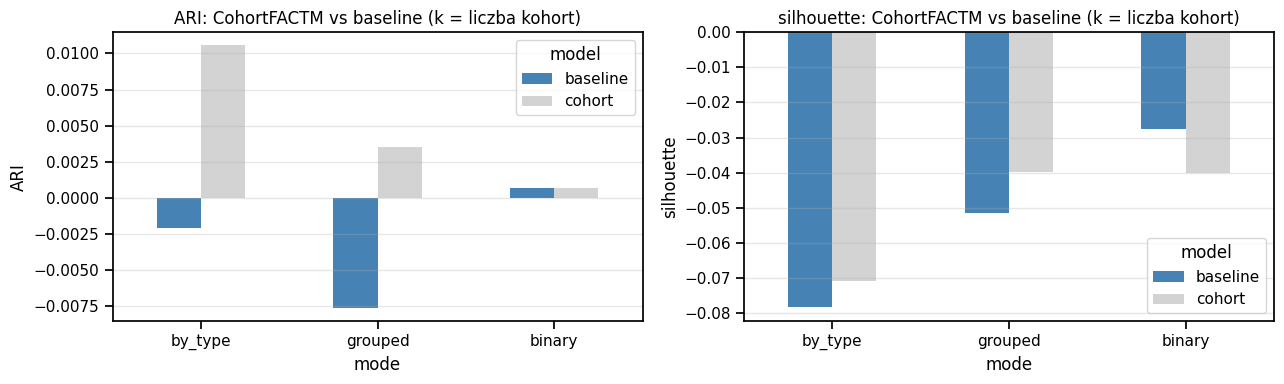

In [ ]:
rows = []
for mode in ['by_type', 'grouped', 'binary']:
    d = get_data(mode)
    views = d.views
    _, codes = np.unique(d.cohorts, return_inverse=True)
    C = len(np.unique(codes))                       # k-means: k = liczba kohort
    for kind in ['cohort', 'baseline']:
        m = get_fit(mode, kind, K=HEADLINE_K)
        Z = m.get_latent_factors()
        lab = KMeans(n_clusters=C, n_init=10, random_state=0).fit_predict(Z)
        h, comp, v = homogeneity_completeness_v_measure(codes, lab)
        rows.append({'mode': mode, 'model': kind, 'k': C,
                     'ELBO': float(m.elbo_sequence[-1]),
                     'R2': mean_r2(m, views),
                     'silhouette': float(silhouette_score(Z, codes)),
                     'ARI': adjusted_rand_score(codes, lab),
                     'NMI': normalized_mutual_info_score(codes, lab),
                     'AMI': adjusted_mutual_info_score(codes, lab),
                     'V_measure': v,
                     'FMI': fowlkes_mallows_score(codes, lab)})
df_rec = pd.DataFrame(rows)
print('Porownanie per partycja (k-means k = liczba kohort):')
print(df_rec.round(3).to_string(index=False))

# Różnica cohort - baseline dla każdej metryki (dla wszystkich tu: wyżej = lepiej)
metr = ['ELBO', 'R2', 'silhouette', 'ARI', 'NMI', 'AMI', 'V_measure', 'FMI']
gap = []
for mode in ['by_type', 'grouped', 'binary']:
    sub = df_rec[df_rec['mode'] == mode].set_index('model')
    gap.append({'mode': mode,
                **{f'Δ{x}': round(float(sub.loc['cohort', x] - sub.loc['baseline', x]), 3)
                   for x in metr}})
df_gap = pd.DataFrame(gap)
print('\nRóżnica cohort - baseline (dodatnia = cohort lepszy):')
print(df_gap.to_string(index=False))

# Wykres: ARI i silhouette obok siebie, cohort vs baseline, per partycja
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric in zip(axes, ['ARI', 'silhouette']):
    piv = df_rec.pivot(index='mode', columns='model', values=metric).loc[
        ['by_type', 'grouped', 'binary']]
    piv.plot.bar(ax=ax, color=['steelblue', 'lightgray'], rot=0)
    ax.set_ylabel(metric); ax.set_title(f'{metric}: CohortFACTM vs baseline (k = liczba kohort)')
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

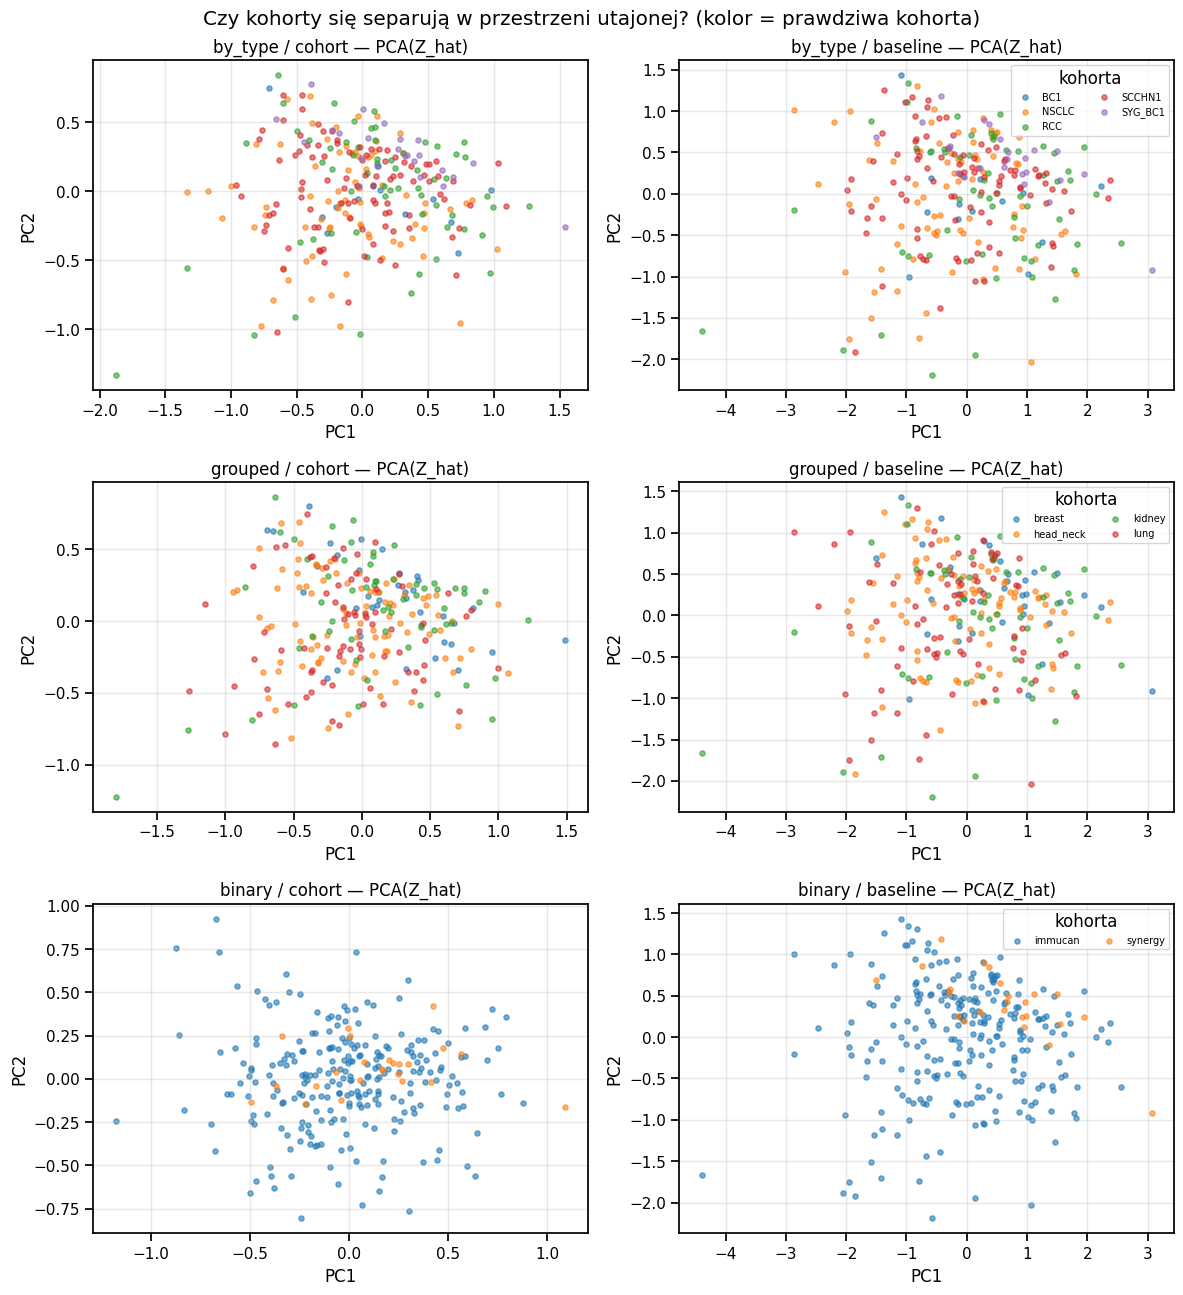

In [30]:
# 8e — wizualny dowód: czy kohorty tworzą skupiska w Z_hat? PCA cohort vs baseline (3 partycje)
modes = ['by_type', 'grouped', 'binary']
fig, axes = plt.subplots(len(modes), 2, figsize=(12, 4.4 * len(modes)))
for r, mode in enumerate(modes):
    d = get_data(mode)
    names, codes = np.unique(d.cohorts, return_inverse=True)
    for cax, kind in zip(axes[r], ['cohort', 'baseline']):
        Z = get_fit(mode, kind, K=HEADLINE_K).get_latent_factors()
        P = PCA(n_components=2).fit_transform(Z)
        for i, name in enumerate(names):
            msk = codes == i
            cax.scatter(P[msk, 0], P[msk, 1], s=14, alpha=0.6, label=name)
        cax.set_title(f'{mode} / {kind} — PCA(Z_hat)')
        cax.set_xlabel('PC1'); cax.set_ylabel('PC2'); cax.grid(alpha=0.3)
    axes[r, 1].legend(fontsize=7, ncol=2, title='kohorta')
plt.suptitle('Czy kohorty się separują w przestrzeni utajonej? (kolor = prawdziwa kohorta)')
plt.tight_layout(); plt.show()

### 8e-bis — Odzysk kohort dla wszystkich `pi`

In [31]:
# 8e-bis — metryki klastrowania (odzysk kohort, k-means k=#kohort) dla WSZYSTKICH pi
# Porownanie per partycja jak w 8d, ale sweep po pi (by_type, K=5). Reużywa fity z sek. 6.
mode = 'by_type'
d = get_data(mode)
_, codes = np.unique(d.cohorts, return_inverse=True)
C = len(np.unique(codes))
rows = []
for pi in PI_GRID:
    Z = get_fit(mode, 'cohort', K=HEADLINE_K, pi=pi).get_latent_factors()
    lab = KMeans(n_clusters=C, n_init=10, random_state=0).fit_predict(Z)
    h, comp, v = homogeneity_completeness_v_measure(codes, lab)
    rows.append({'pi': pi, 'k': C,
                 'silhouette': float(silhouette_score(Z, codes)),
                 'ARI': float(adjusted_rand_score(codes, lab)),
                 'NMI': float(normalized_mutual_info_score(codes, lab)),
                 'AMI': float(adjusted_mutual_info_score(codes, lab)),
                 'V_measure': float(v),
                 'FMI': float(fowlkes_mallows_score(codes, lab))})
df_pi_clust = pd.DataFrame(rows)
print('Porownanie per pi — odzysk kohort (k-means, k = liczba kohort), by_type:')
print(df_pi_clust.round(3).to_string(index=False))

Porownanie per pi — odzysk kohort (k-means, k = liczba kohort), by_type:
 pi  k  silhouette   ARI   NMI   AMI  V_measure   FMI
0.1  5      -0.070 0.010 0.057 0.036      0.057 0.257
0.3  5      -0.070 0.010 0.057 0.036      0.057 0.257
0.5  5      -0.071 0.011 0.058 0.038      0.058 0.259
0.7  5      -0.071 0.009 0.057 0.036      0.057 0.259
0.9  5      -0.071 0.011 0.058 0.038      0.058 0.259


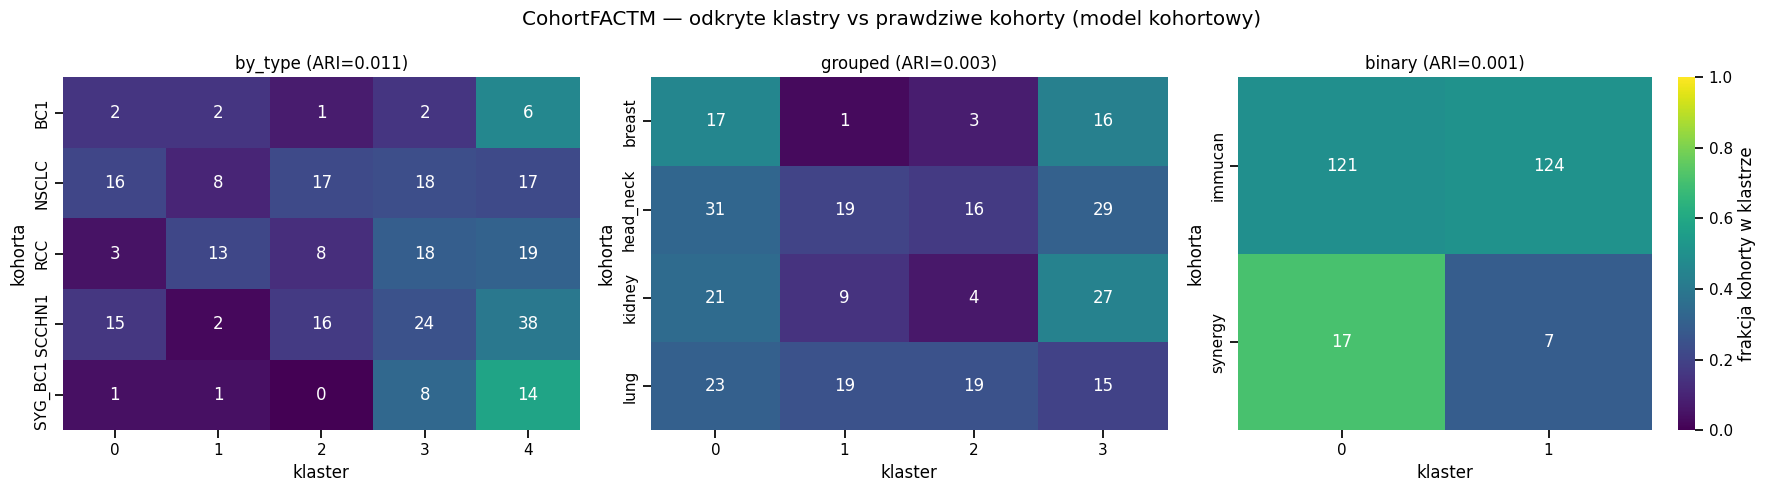

In [32]:
# 8f — macierz zgodności: odkryte klastry (k-means, k = liczba kohort) vs prawdziwe kohorty (3 partycje)
modes = ['by_type', 'grouped', 'binary']
fig, axes = plt.subplots(1, len(modes), figsize=(6 * len(modes), 5))
for ax, mode in zip(axes, modes):
    d = get_data(mode)
    names, codes = np.unique(d.cohorts, return_inverse=True)
    C = len(names)
    Z = get_fit(mode, 'cohort', K=HEADLINE_K).get_latent_factors()
    lab = KMeans(n_clusters=C, n_init=10, random_state=0).fit_predict(Z)
    ct = pd.crosstab(pd.Series(d.cohorts, name='kohorta'), pd.Series(lab, name='klaster'))
    ct_norm = ct.div(ct.sum(axis=1), axis=0)
    sns.heatmap(ct_norm, annot=ct.values, fmt='d', cmap='viridis', vmin=0, vmax=1,
                cbar=(ax is axes[-1]),
                cbar_kws={'label': 'frakcja kohorty w klastrze'}, ax=ax)
    ax.set_title(f'{mode} (ARI={adjusted_rand_score(codes, lab):.3f})')
plt.suptitle('CohortFACTM — odkryte klastry vs prawdziwe kohorty (model kohortowy)')
plt.tight_layout(); plt.show()

 pi  silhouette  davies_bouldin  calinski_harabasz  within/between
0.1      -0.070           6.000              4.032           2.023
0.3      -0.070           6.000              4.032           2.023
0.5      -0.071           5.943              4.128           1.998
0.7      -0.071           5.937              4.141           1.994
0.9      -0.071           5.930              4.149           1.992


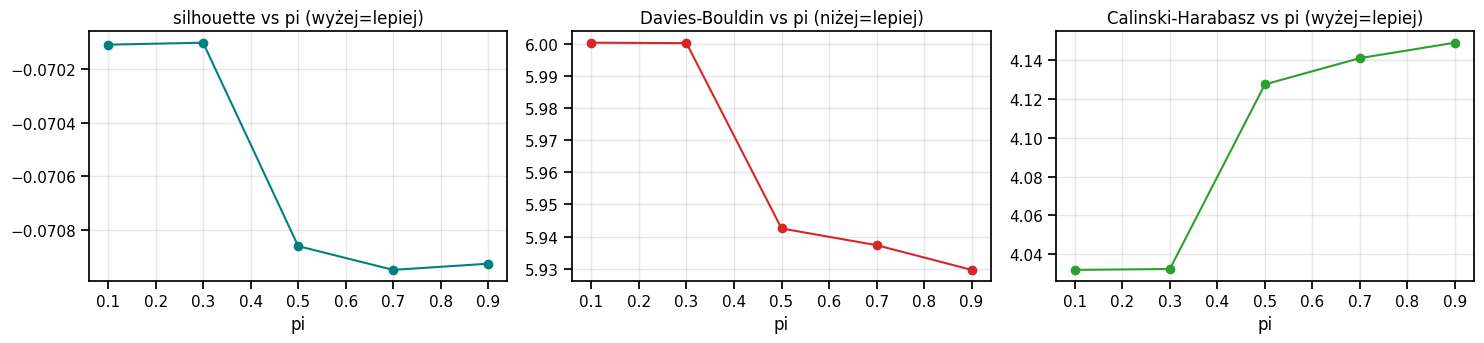

In [33]:
# 8g — jak separacja kohort zależy od pi (by_type, K=5) — reużywa fitów z sekcji 6
mode = 'by_type'
codes = np.unique(get_data(mode).cohorts, return_inverse=True)[1]
rows = []
for pi in PI_GRID:
    mp = get_fit(mode, 'cohort', K=HEADLINE_K, pi=pi)
    rows.append({'pi': pi, **clustering_metrics(mp.get_latent_factors(), codes)})
df_sil = pd.DataFrame(rows)
print(df_sil.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].plot(df_sil['pi'], df_sil['silhouette'], 'o-', color='teal')
axes[0].set_title('silhouette vs pi (wyżej=lepiej)')
axes[1].plot(df_sil['pi'], df_sil['davies_bouldin'], 'o-', color='C3')
axes[1].set_title('Davies-Bouldin vs pi (niżej=lepiej)')
axes[2].plot(df_sil['pi'], df_sil['calinski_harabasz'], 'o-', color='C2')
axes[2].set_title('Calinski-Harabasz vs pi (wyżej=lepiej)')
for ax in axes:
    ax.set_xlabel('pi'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9 — Wagi `W`, istotność faktorów i topiki CTM (z `02_w_loadings`)

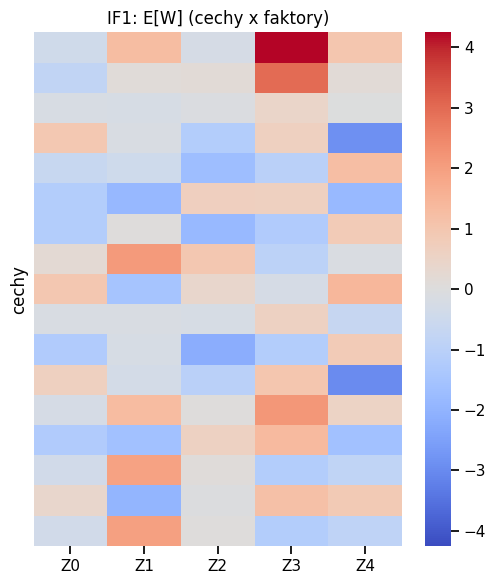

In [34]:
# 9a — nauczone ładunki E[W] per widok (by_type, K=5)
mode = 'by_type'
mc = get_fit(mode, 'cohort', K=HEADLINE_K)
views = get_data(mode).views
factors = [f'Z{k}' for k in range(HEADLINE_K)]
_panels = globals().get('IMMUCAN_PANELS', ('IF1',))
view_names = [
    _panels[i] if i < len(_panels) else f'simple_{i}'
    for i in range(views.num_simple)
]

n_v = views.num_simple
fig, axes = plt.subplots(1, n_v, figsize=(5.2 * max(n_v, 1), 6), squeeze=False)
axes = axes.ravel()
for v in range(n_v):
    E_w = get_W(mc, v)
    vmax = np.abs(E_w).max() or 1.0
    sns.heatmap(E_w, cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
                xticklabels=factors, yticklabels=False, ax=axes[v])
    axes[v].set_title(f'{view_names[v]}: E[W] (cechy x faktory)')
    axes[v].set_ylabel('cechy')
plt.tight_layout(); plt.show()

In [35]:
def feature_names_for_view(long_df, view_name):
    sub = long_df[long_df['view'] == view_name]
    pivot = sub.pivot_table(index='sample', columns='feature', values='value', aggfunc='first')
    return pivot.columns.tolist()

# 9c — top cechy per faktor (które cechy IF najsilniej go budują)
d = get_data(mode)
feat_names = {}
for vi, vname in enumerate(view_names):
    panel = sorted(d.long_df['view'].unique())[vi]
    feat_names[vname] = feature_names_for_view(d.long_df, panel)
TOPN = 10

rows = []
for k in range(HEADLINE_K):
    for v, vname in enumerate(view_names):
        W = get_W(mc, v)
        col = W[:, k]
        order_pos = np.argsort(col)[::-1][:TOPN]
        order_neg = np.argsort(col)[:TOPN]
        rows.append({'faktor': f'Z{k}', 'widok': vname, 'kierunek': 'top+',
                     'cechy': ', '.join(feat_names[vname][i] for i in order_pos)})
        rows.append({'faktor': f'Z{k}', 'widok': vname, 'kierunek': 'top-',
                     'cechy': ', '.join(feat_names[vname][i] for i in order_neg)})
df_top = pd.DataFrame(rows)
print(df_top.to_string(index=False))


faktor widok kierunek                                                                                                                                                                                                                    cechy
    Z0   IF1     top+              celltype_other_view0, celltype_MacCD163_view0, marker_CD163_view0, tissue_stroma_view0, celltype_Tumor_view0, marker_CD11c_view0, celltype_DC_view0, marker_CD20_view0, tissue_tumor_view0, marker_CK_view0
    Z0   IF1     top-                marker_CD3_view0, marker_CD15_view0, celltype_T_view0, celltype_Tumor_CD15_view0, celltype_BnT_view0, celltype_Neutrophil_view0, celltype_B_view0, marker_CK_view0, tissue_tumor_view0, marker_CD20_view0
    Z1   IF1     top+            celltype_Tumor_view0, tissue_tumor_view0, marker_CK_view0, marker_CD20_view0, celltype_B_view0, celltype_BnT_view0, celltype_Tumor_CD15_view0, celltype_MacCD163_view0, marker_CD11c_view0, celltype_DC_view0
    Z1   IF1     top-          tissue_stroma

    ‖W[:,k]‖ (energia)  1/E[alpha] (ARD)  var(Z[:,k])
Z0               3.148             0.587        0.231
Z1               5.308             1.665        0.131
Z2               3.940             0.920        0.137
Z3               6.728             2.677        0.060
Z4               5.689             1.916        0.077


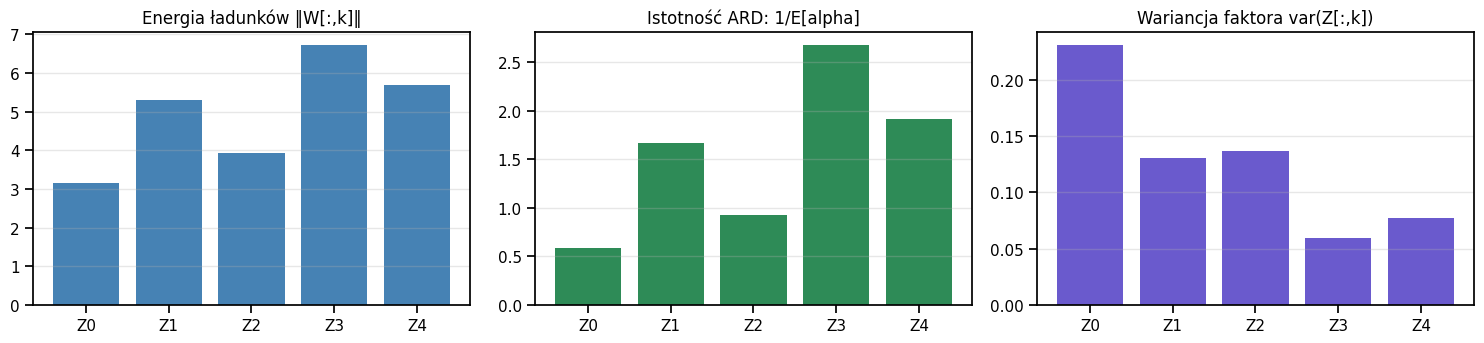

In [36]:
# 9b — istotność faktorów: energia ‖W‖, ARD 1/E[alpha], var(Z)
W0 = get_W(mc, 0)
energy = np.linalg.norm(W0, axis=0)
relevance = 1.0 / factor_alpha(mc, 0)
zvar = mc.get_latent_factors().var(0)
tab = pd.DataFrame({'‖W[:,k]‖ (energia)': energy.round(3),
                    '1/E[alpha] (ARD)':   relevance.round(3),
                    'var(Z[:,k])':        zvar.round(3)}, index=factors)
print(tab.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].bar(factors, energy, color='steelblue');  axes[0].set_title('Energia ładunków ‖W[:,k]‖')
axes[1].bar(factors, relevance, color='seagreen'); axes[1].set_title('Istotność ARD: 1/E[alpha]')
axes[2].bar(factors, zvar, color='slateblue');     axes[2].set_title('Wariancja faktora var(Z[:,k])')
for ax in axes:
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

### 9d — Macierz R²: które faktory wyjaśniają które widoki / kohorty

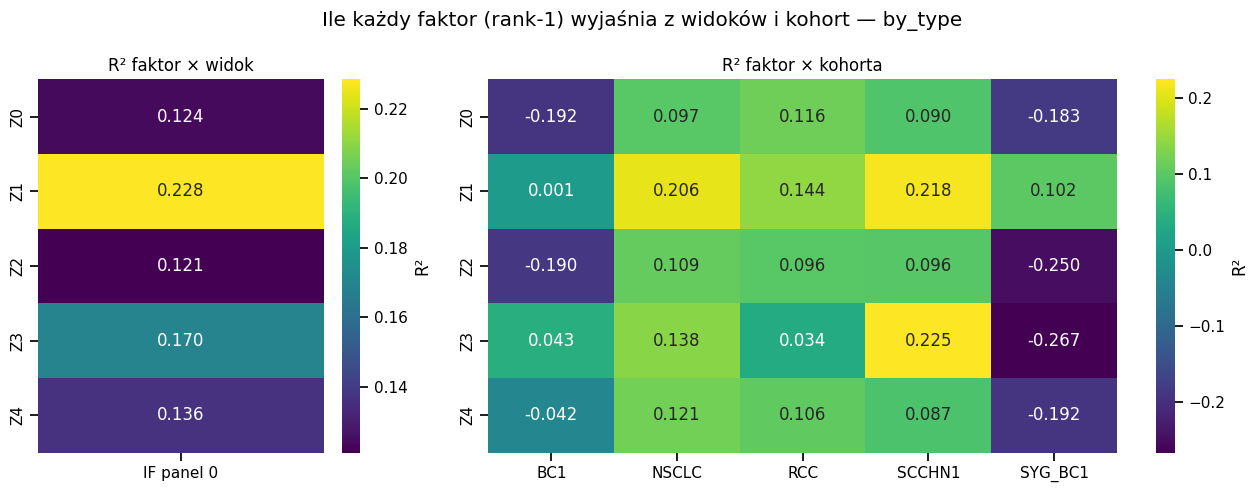

In [37]:
# 9d — macierz R²: ile każdy FAKTOR wyjaśnia z każdego WIDOKU i każdej KOHORTY
# Rekonstrukcja rank-1 z pojedynczego faktora: Ŷ_k = Z[:,k] ⊗ W[:,k]; R² = 1 - SS_res/SS_tot.
mode = 'by_type'
d = get_data(mode); views = d.views
mc = get_fit(mode, 'cohort', K=HEADLINE_K)
Z = mc.get_latent_factors()
names, codes = np.unique(d.cohorts, return_inverse=True)
fl = [f'Z{k}' for k in range(HEADLINE_K)]
view_names = [f'IF panel {i}' for i in range(views.num_simple)]


def var_expl(Y, Yh):
    return 1.0 - ((Y - Yh) ** 2).sum() / ((Y - Y.mean(0)) ** 2).sum()


# faktor × widok
R2_fv = np.zeros((HEADLINE_K, views.num_simple))
for k in range(HEADLINE_K):
    for vi in range(views.num_simple):
        Yh_k = np.outer(Z[:, k], get_W(mc, vi)[:, k])
        R2_fv[k, vi] = var_expl(np.asarray(views.simple[vi].data), Yh_k)

# faktor × kohorta (sklejone widoki; R² na próbkach danej kohorty)
Ycat = np.hstack([np.asarray(views.simple[vi].data) for vi in range(views.num_simple)])
R2_fc = np.zeros((HEADLINE_K, len(names)))
for k in range(HEADLINE_K):
    Yh_k = np.hstack([np.outer(Z[:, k], get_W(mc, vi)[:, k]) for vi in range(views.num_simple)])
    for ci in range(len(names)):
        m = codes == ci
        R2_fc[k, ci] = var_expl(Ycat[m], Yh_k[m])

fig, axes = plt.subplots(1, 2, figsize=(13, 0.5 * HEADLINE_K + 2.5),
                         gridspec_kw={'width_ratios': [1, 2.2]})
sns.heatmap(R2_fv, annot=True, fmt='.3f', cmap='viridis',
            xticklabels=view_names, yticklabels=fl, ax=axes[0], cbar_kws={'label': 'R²'})
axes[0].set_title('R² faktor × widok')
sns.heatmap(R2_fc, annot=True, fmt='.3f', cmap='viridis',
            xticklabels=names, yticklabels=fl, ax=axes[1], cbar_kws={'label': 'R²'})
axes[1].set_title('R² faktor × kohorta')
plt.suptitle('Ile każdy faktor (rank-1) wyjaśnia z widoków i kohort — by_type')
plt.tight_layout(); plt.show()

### 9e — Topiki CTM spatial: różnice między 

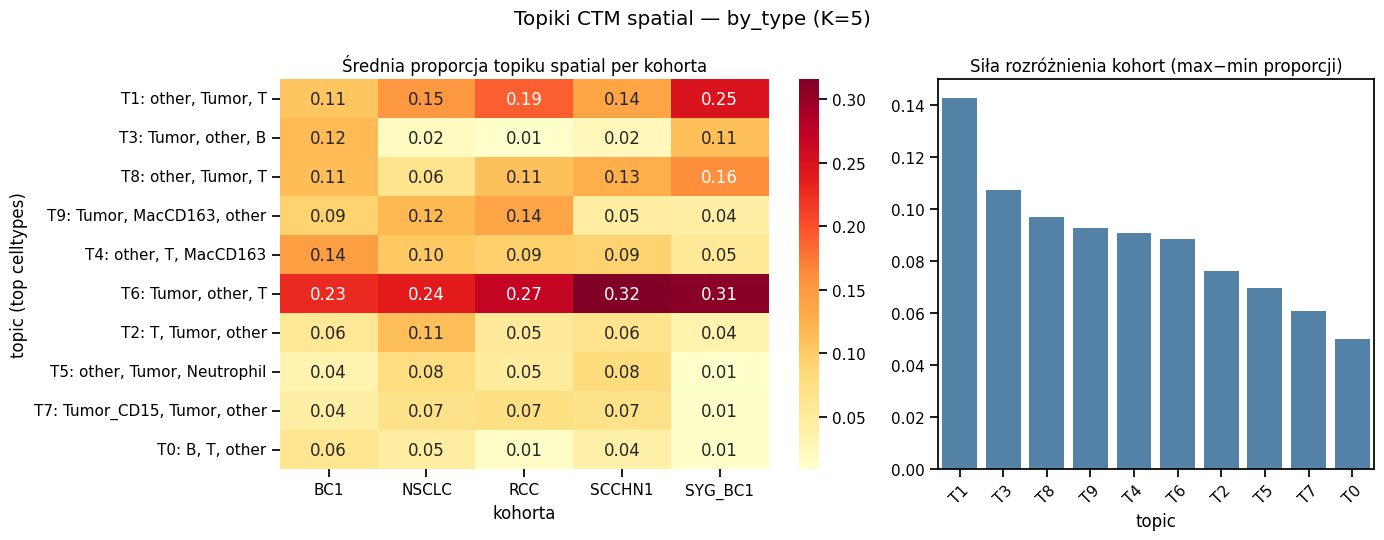

In [38]:
# 9e — proporcje topików spatial per kohorta + ranking rozróżnienia
mode = 'by_type'
d = get_data(mode)
mc = get_fit(mode, 'cohort', K=HEADLINE_K)
cohorts = d.cohorts

names, prof = cohort_topic_profiles(mc, cohorts, struct_idx=0)
vocab = d.celltype_vocab
beta = topic_celltype_matrix(mc, struct_idx=0)
topic_labels = [f'T{t}: {s}' for t, s in enumerate(top_celltypes_per_topic(beta, vocab))]

disc = topic_discrimination_scores(prof)
order = np.argsort(disc)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, 0.35 * len(topic_labels) + 2)),
                         gridspec_kw={'width_ratios': [1.4, 1]})
sns.heatmap(prof[:, order].T, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=names,
            yticklabels=[topic_labels[i] for i in order], ax=axes[0])
axes[0].set_title('Średnia proporcja topiku spatial per kohorta')
axes[0].set_xlabel('kohorta')
axes[0].set_ylabel('topic (top celltypes)')

sns.barplot(x=[f'T{i}' for i in order], y=disc[order], ax=axes[1], color='steelblue')
axes[1].set_title('Siła rozróżnienia kohort (max−min proporcji)')
axes[1].set_xlabel('topic')
axes[1].tick_params(axis='x', rotation=45)
plt.suptitle(f'Topiki CTM spatial — {mode} (K={HEADLINE_K})')
plt.tight_layout()
plt.show()


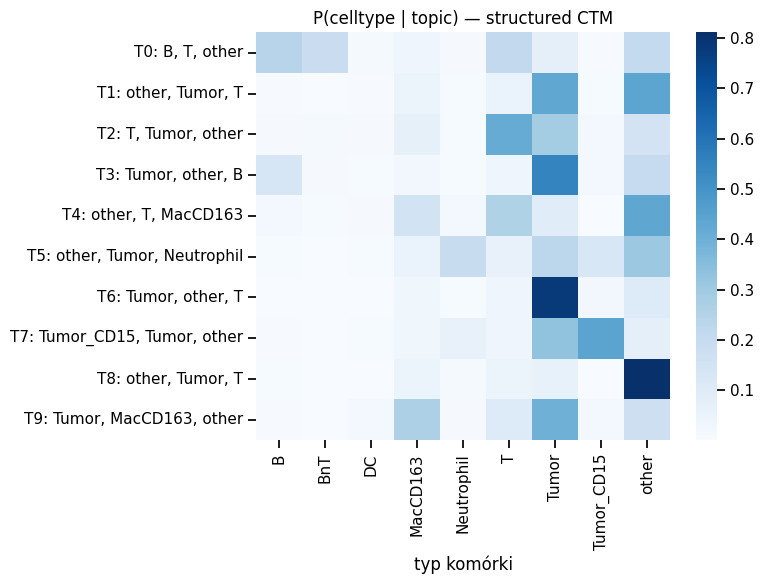

In [39]:
# Skład β: co biologicznie oznacza każdy topic (P(celltype | topic))
fig, ax = plt.subplots(figsize=(8, 0.45 * len(topic_labels) + 1.5))
sns.heatmap(beta, cmap='Blues', xticklabels=vocab, yticklabels=topic_labels, ax=ax)
ax.set_title('P(celltype | topic) — structured CTM')
ax.set_xlabel('typ komórki')
plt.tight_layout()
plt.show()


### 9h — Powiązanie czynników FA z topikami CTM (`E[W]` structured)


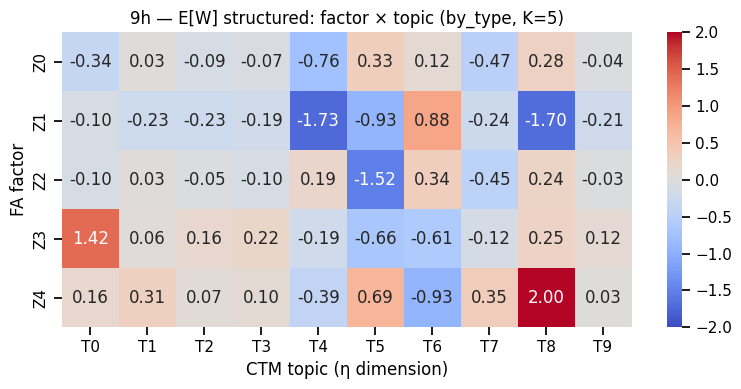

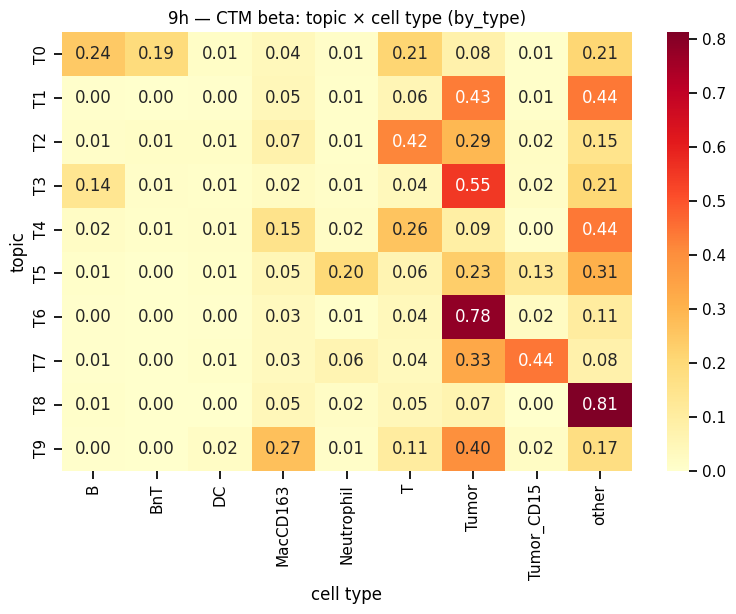

structured W (L×K): (10, 5)  beta (L×G): (10, 9)  linkage (K×L): (5, 10)
Top |link| per factor:
  Z0 -> T4  score=-0.762
  Z1 -> T4  score=-1.732
  Z2 -> T5  score=-1.517
  Z3 -> T0  score=1.419
  Z4 -> T8  score=2.000


In [40]:
from immucan_data.loader import DEFAULT_SPATIAL_WINDOW_SIZE
from immucan_data import viz as immucan_viz

STRUCTURED_IDX = 0
SPATIAL_WINDOW_SIZE = DEFAULT_SPATIAL_WINDOW_SIZE
MAX_WINDOWS_PER_SAMPLE = 500

mode = 'by_type'
d = get_data(mode)
mc = get_fit(mode, 'cohort', K=HEADLINE_K)

immucan_viz.plot_factor_topic_heatmap(
    mc, K=HEADLINE_K, structured_idx=STRUCTURED_IDX,
    title=f'9h — E[W] structured: factor × topic ({mode}, K={HEADLINE_K})',
)
plt.show()

immucan_viz.plot_topic_celltype_heatmap(
    mc,
    list(d.celltype_vocab),
    structured_idx=STRUCTURED_IDX,
    title=f'9h — CTM beta: topic × cell type ({mode})',
)
plt.show()

W_s = immucan_viz.get_W_structured(mc, STRUCTURED_IDX)
beta_s = np.asarray(mc.get_topics(STRUCTURED_IDX))
link = immucan_viz.factor_topic_linkage(mc, STRUCTURED_IDX)
print(f'structured W (L×K): {W_s.shape}  beta (L×G): {beta_s.shape}  linkage (K×L): {link.shape}')
print('Top |link| per factor:')
for k in range(HEADLINE_K):
    l_best = int(np.argmax(np.abs(link[k])))
    print(f'  Z{k} -> T{l_best}  score={link[k, l_best]:.3f}')


### 9i — Topiki na tkance (przedstawiciele kohort)

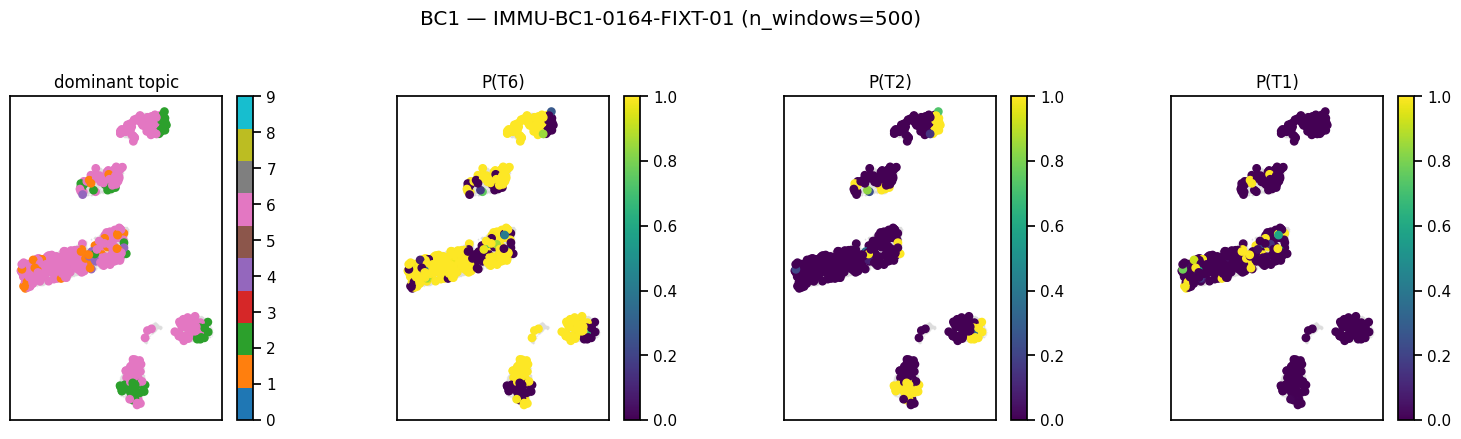

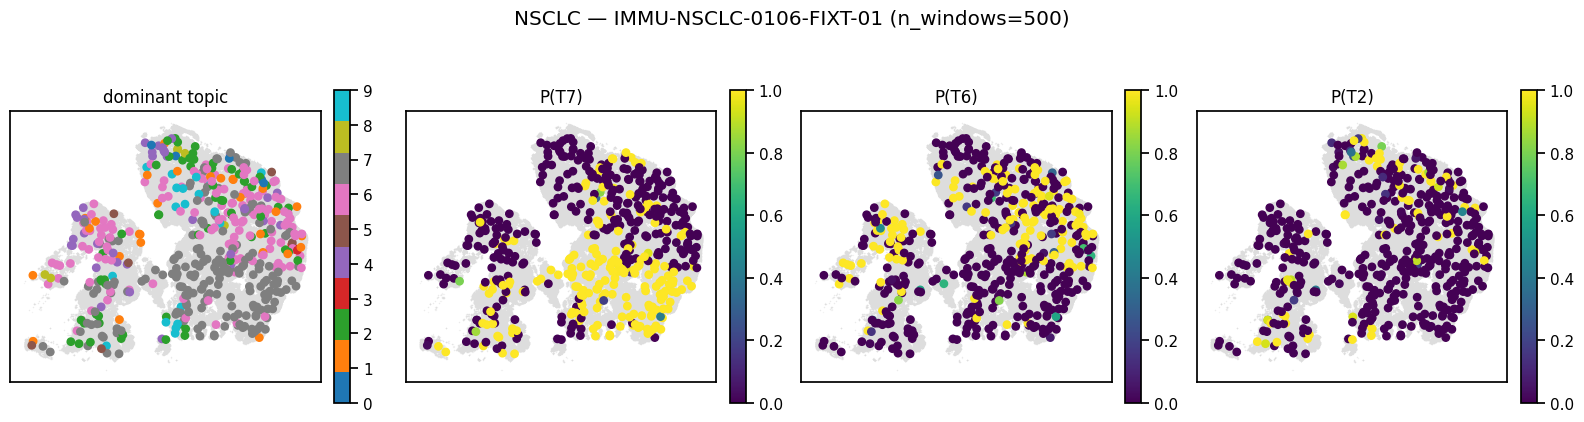

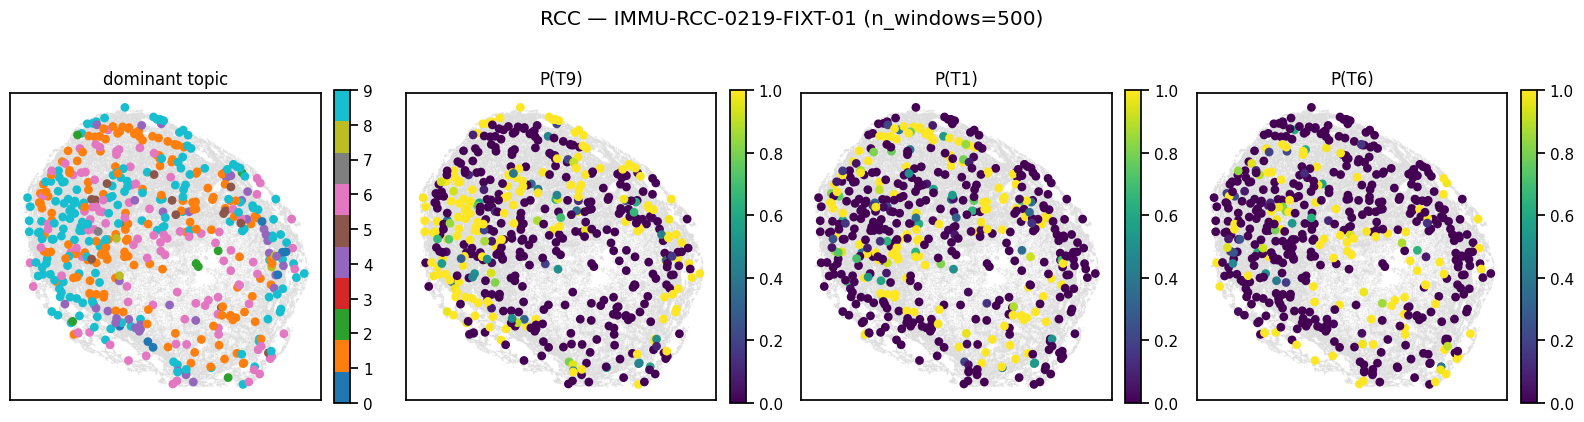

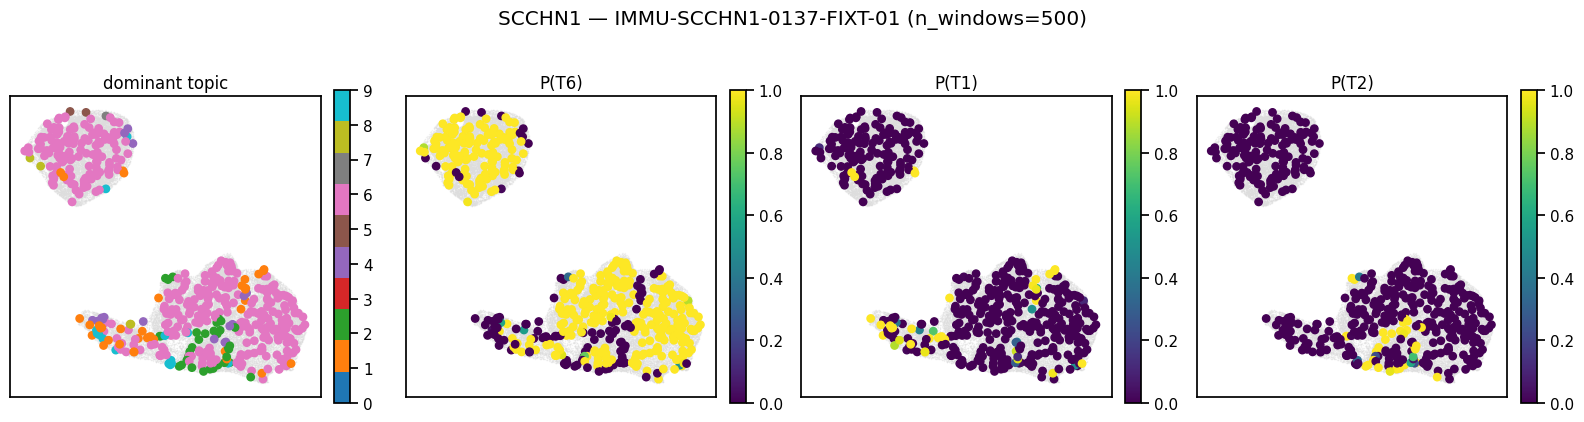

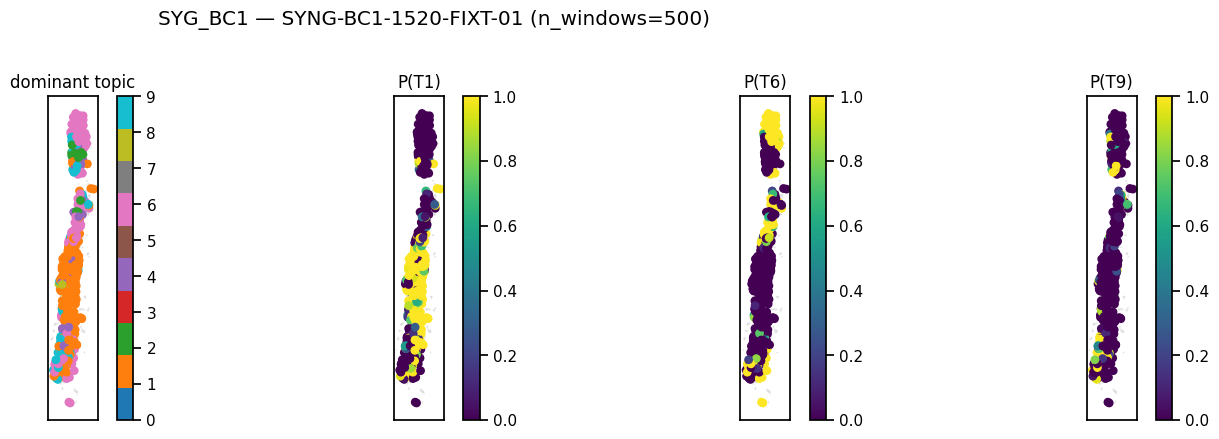

In [41]:
rep = immucan_viz.first_sample_index_per_cohort(d.cohorts, d.sample_ids)
manifest_kw = dict(
    cohorts=IMMUCAN_COHORTS,
    sample_ids=IMMUCAN_SAMPLE_IDS,
    first_n_per_cohort=FIRST_N_PER_COHORT,
    max_samples_per_cohort=None,
)
panel = IMMUCAN_PANELS[0]

for cohort_name, sample_idx in sorted(rep.items()):
    sample_id = str(d.sample_ids[sample_idx])
    cells, center_idx, topic_probs = immucan_viz.topic_probs_and_centers_for_sample(
        mc,
        d,
        sample_idx,
        structured_idx=STRUCTURED_IDX,
        root=IMMUCAN_ROOT,
        panel=panel,
        spatial_window_size=SPATIAL_WINDOW_SIZE,
        max_windows_per_sample=MAX_WINDOWS_PER_SAMPLE,
        seed=SEED,
        tumor_roi_only=TUMOR_ROI_ONLY,
        **manifest_kw,
    )
    immucan_viz.plot_spatial_topics_on_tissue(
        cells,
        center_idx,
        topic_probs,
        sample_id=sample_id,
        cohort=cohort_name,
        n_topic_panels=min(3, topic_probs.shape[1]),
    )
    plt.show()


### 9f — Odchylenie proporcji topiku względem średniej globalnej

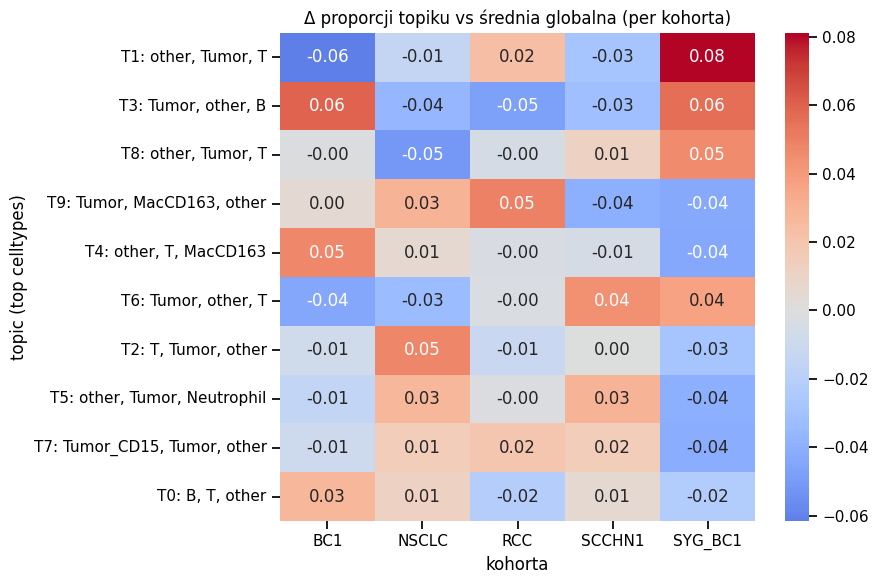

In [42]:
# 9f — Δ proporcji topiku vs średnia globalna (posortowane wg rozróżnienia)
prof_z = prof - prof.mean(axis=0)
fig, ax = plt.subplots(figsize=(9, 0.4 * len(topic_labels) + 2))
sns.heatmap(prof_z[:, order].T, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=names,
            yticklabels=[topic_labels[i] for i in order], ax=ax)
ax.set_title('Δ proporcji topiku vs średnia globalna (per kohorta)')
ax.set_xlabel('kohorta')
ax.set_ylabel('topic (top celltypes)')
plt.tight_layout()
plt.show()


### 9g — Tabela: które kohorty wyróżniają się na rozróżniających topikach

In [43]:
# 9g — tabela wzbogacenia/deficytu per topic
df_topics = topic_cohort_enrichment_table(names, prof, topic_labels, order=order, topn=5)
print('Top 5 topików rozróżniających kohorty:\n')
print(df_topics.to_string(index=False))

THR = 0.02
detail_rows = []
for ci, cname in enumerate(names):
    for t in order:
        delta = prof_z[ci, t]
        if abs(delta) >= THR:
            detail_rows.append({
                'kohorta': cname,
                'topic': topic_labels[t],
                'delta_vs_srednia': round(float(delta), 3),
                'kierunek': 'więcej' if delta > 0 else 'mniej',
            })
if detail_rows:
    df_detail = pd.DataFrame(detail_rows).sort_values(['kohorta', 'delta_vs_srednia'],
                                                         ascending=[True, False])
    print(f'\nOdchylenia |Δ| ≥ {THR} (kohorta × topic):\n')
    print(df_detail.to_string(index=False))
else:
    print(f'\nBrak odchyleń |Δ| ≥ {THR} — obniż THR lub sprawdź liczebność kohort.')


Top 5 topików rozróżniających kohorty:

                     topic max_kohorta  max_prop min_kohorta  min_prop  roznica_max_min
       T1: other, Tumor, T     SYG_BC1     0.248         BC1     0.105            0.143
       T3: Tumor, other, B         BC1     0.116         RCC     0.009            0.107
       T8: other, Tumor, T     SYG_BC1     0.161       NSCLC     0.064            0.097
T9: Tumor, MacCD163, other         RCC     0.137     SYG_BC1     0.044            0.093
    T4: other, T, MacCD163         BC1     0.144     SYG_BC1     0.054            0.091

Odchylenia |Δ| ≥ 0.02 (kohorta × topic):

kohorta                        topic  delta_vs_srednia kierunek
    BC1          T3: Tumor, other, B             0.060   więcej
    BC1       T4: other, T, MacCD163             0.047   więcej
    BC1              T0: B, T, other             0.028   więcej
    BC1          T6: Tumor, other, T            -0.045    mniej
    BC1          T1: other, Tumor, T            -0.062    mniej
  NSC